# Lab 05: RNNs vs. Transformers vs. Vision Transformers
## ITAI 2376 — Deep Learning | Spring 2026
### Houston City College — AI & Robotics Program

---

**Welcome to Lab 05!** This is a comprehensive, hands-on lab where you will build, train, and compare three major deep learning architectures:

| Part | Architecture | Task | Dataset |
|------|-------------|------|---------|
| **A** | LSTM & GRU (RNNs) | News Topic Classification | AG News |
| **B** | DistilBERT (Transformer) | News Topic Classification | AG News (same data!) |
| **C** | Vision Transformer (ViT) | Image Classification | CIFAR-10 |
| **D** | — | Comparative Analysis & Reflection | All results |

**Why this lab matters:** By using the *same text dataset* for both RNNs and Transformers, you get a direct, apples-to-apples comparison. Then, by exploring Vision Transformers, you see how the Transformer idea extends beyond text into images — and you can compare ViT performance to the CNNs you built in Module 03.

**Estimated Time:** 3–4 hours  
**Environment:** Google Colab (free tier is sufficient)

---

⚠️ **Important:** Run cells in order. If you restart the runtime, re-run all cells from the top.

---
## Part 0: Environment Setup

First, let's install libraries and check GPU access. GPU is not strictly required but makes training much faster.

**If no GPU:** Runtime → Change runtime type → T4 GPU. If unavailable, reduce epochs or dataset size as noted in the troubleshooting section at the end.

In [ ]:
# Cell 0.1 — Install Required Libraries
# This cell installs the external libraries needed for this lab:
#   - transformers: Hugging Face library for pre-trained models (BERT, ViT)
#   - datasets: Hugging Face library for loading standard datasets (AG News, CIFAR-10)
#   - accelerate: Helps optimize training on different hardware (GPU/CPU)
# The -q flag makes installation quiet (less verbose output)

!pip install transformers datasets accelerate -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [ ]:
# Cell 0.2 — Import Core Libraries and Check GPU Availability

# ========== DEEP LEARNING FRAMEWORK ==========
import torch                          # PyTorch: main deep learning framework
import torch.nn as nn                 # Neural network modules (layers, loss functions)
import torch.optim as optim           # Optimization algorithms (Adam, SGD, etc.)
from torch.utils.data import DataLoader, Dataset  # Data loading utilities for batching

# ========== DATA PROCESSING ==========
import numpy as np                    # Numerical operations on arrays
from collections import Counter       # Count word frequencies for vocabulary building
import re                             # Regular expressions for text cleaning

# ========== VISUALIZATION ==========
import matplotlib.pyplot as plt       # Plotting library for charts and graphs

# ========== UTILITIES ==========
import time                           # Track training time per epoch
import warnings                       # Suppress non-critical warnings
warnings.filterwarnings('ignore')     # Hide deprecation and other warnings for cleaner output

# ========== HUGGING FACE LIBRARIES (imported later when needed) ==========
# from datasets import load_dataset   # For loading AG News dataset
# from transformers import ...        # For DistilBERT and ViT models
# from torchvision import ...         # For CIFAR-10 dataset and image transforms

# ========== DEVICE CONFIGURATION ==========
# Check if CUDA-enabled GPU is available; otherwise use CPU
# Training on GPU is 10-50x faster than CPU for deep learning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

if device.type == 'cuda':
    # Display GPU name (e.g., Tesla T4, A100)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU detected. Training will be slower. See troubleshooting tips at end.")

🖥️  Device: cuda
   GPU: Tesla T4


---
# Part A: RNN Text Classification (LSTM & GRU)

In Module 04, you learned about Recurrent Neural Networks — architectures that process sequences step by step, maintaining a hidden state that acts as "memory." Now you put that knowledge into practice.

**Your task:** Build LSTM and GRU classifiers to categorize news articles into four topics:
- 🌍 **World** — international news
- 🏈 **Sports** — athletic events
- 💼 **Business** — financial and corporate news
- 🔬 **Sci/Tech** — science and technology

We use the **AG News** dataset — a well-known benchmark. We use a subset to keep training fast on free Colab.

### Step A.1 — Load and Explore AG News

In [ ]:
# Cell A.1 — Load AG News Dataset
# Import the Hugging Face datasets library for easy access to standard datasets
from datasets import load_dataset

# Load the AG News dataset (4-class news topic classification)
# This dataset contains news articles labeled as: World, Sports, Business, Sci/Tech
dataset = load_dataset("ag_news")

# Define subset sizes to keep training time reasonable on free Colab
TRAIN_SIZE = 8000  # 2000 samples per class (4 classes × 2000 = 8000)
TEST_SIZE  = 2000  # 500 samples per class (4 classes × 500 = 2000)

# Shuffle and select subsets (seed=42 ensures reproducibility)
train_data = dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_data  = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

# Define human-readable class names (labels are 0, 1, 2, 3)
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

# Display dataset information
print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")
print(f"\n--- Sample article ---")
print(f"Label: {CLASS_NAMES[train_data[0]['label']]}")
print(f"Text:  {train_data[0]['text'][:300]}...")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Training samples: 8000
Test samples:     2000

--- Sample article ---
Label: World
Text:  Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally....


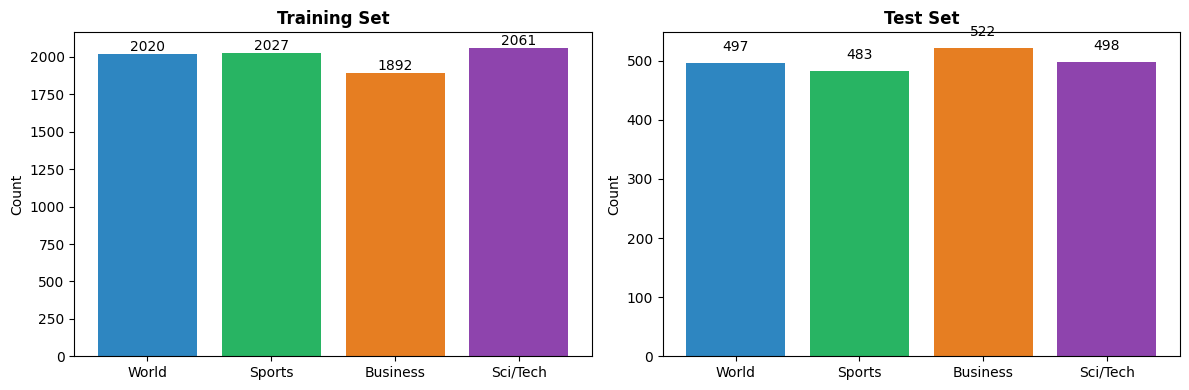

In [ ]:
# Cell A.2 — Visualize Class Distribution
# It's important to check if classes are balanced (equal representation)
# Imbalanced datasets can bias the model toward majority classes

# Extract labels from training and test sets
train_labels = [s['label'] for s in train_data]
test_labels = [s['label'] for s in test_data]

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, title in zip(axes, [train_labels, test_labels], ['Training Set', 'Test Set']):
    # Count occurrences of each class
    counts = Counter(labels)
    # Create bar chart with distinct colors for each class
    bars = ax.bar(CLASS_NAMES, [counts[i] for i in range(4)],
                   color=['#2E86C1','#28B463','#E67E22','#8E44AD'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    # Add count labels on top of each bar
    for bar, c in zip(bars, [counts[i] for i in range(4)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(c), ha='center')

plt.tight_layout()
plt.show()

### Step A.2 — Text Preprocessing

Neural networks cannot process raw text. We need to:
1. **Tokenize** — split text into words
2. **Build a vocabulary** — assign a unique number to each word
3. **Convert to sequences** — replace words with numbers
4. **Pad sequences** — make all sequences the same length for batching

This is the same pipeline from Module 04, implemented from scratch.

In [ ]:
# Cell A.3 — Build Vocabulary and Preprocess Text

def tokenize(text):
    """
    Convert text to lowercase and split into words.

    Steps:
    1. Convert to lowercase ("Hello" and "hello" should be the same word)
    2. Remove punctuation and special characters (keep only letters, numbers, spaces)
    3. Split on whitespace to get individual words

    Example: "Hello, World!" → ["hello", "world"]
    """
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    return text.split()                      # Split into words

# Count word frequencies across all training documents
# This helps us identify the most common words to include in our vocabulary
word_counts = Counter()
for sample in train_data:
    word_counts.update(tokenize(sample['text']))

# ========== VOCABULARY PARAMETERS ==========
VOCAB_SIZE = 10000  # Keep only the 10,000 most common words
MAX_LEN = 128       # Truncate/pad all sequences to 128 tokens
PAD_IDX = 0         # Index for padding token (fills shorter sequences)
UNK_IDX = 1         # Index for unknown words (not in vocabulary)

# Select the top (VOCAB_SIZE - 2) most common words
# We reserve indices 0 and 1 for <PAD> and <UNK>
most_common = word_counts.most_common(VOCAB_SIZE - 2)

# Create word-to-index mapping (dictionary)
# Each word gets a unique integer ID starting from 2
word2idx = {word: idx+2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX  # Special token for padding
word2idx['<UNK>'] = UNK_IDX  # Special token for unknown words

print(f"Vocabulary size: {len(word2idx):,}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Top 10 words: {[w for w, _ in most_common[:10]]}")

Vocabulary size: 10,000
Max sequence length: 128
Top 10 words: ['the', 'to', 'a', 'of', 'in', 'and', 'on', 'for', '39s', 'that']


In [ ]:
# Cell A.4 — Create PyTorch Dataset
# PyTorch requires data in a specific format for efficient batching and loading

class NewsDataset(Dataset):
    """
    Custom PyTorch Dataset for AG News.

    Converts raw text into:
    - Padded sequences of word indices (input for the model)
    - Integer labels (target for classification)
    """
    def __init__(self, data, word2idx, max_len):
        self.texts, self.labels = [], []

        for sample in data:
            # Step 1: Tokenize text and convert words to indices
            # If a word is not in vocabulary, use UNK_IDX
            indices = [word2idx.get(w, UNK_IDX) for w in tokenize(sample['text'])[:max_len]]

            # Step 2: Pad sequence to max_len (add PAD_IDX to the end)
            # This ensures all sequences have the same length for batching
            indices += [PAD_IDX] * (max_len - len(indices))

            # Step 3: Convert to PyTorch tensor
            self.texts.append(torch.tensor(indices, dtype=torch.long))
            self.labels.append(sample['label'])

        # Convert labels to tensor
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.labels)

    def __getitem__(self, idx):
        """Return a single sample (text, label) at the given index."""
        return self.texts[idx], self.labels[idx]

# ========== CREATE DATASETS AND DATA LOADERS ==========
BATCH_SIZE = 64  # Process 64 samples at a time (adjust based on GPU memory)

# Create dataset objects
train_dataset = NewsDataset(train_data, word2idx, MAX_LEN)
test_dataset  = NewsDataset(test_data, word2idx, MAX_LEN)

# Create data loaders (handle batching and shuffling)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Display sample information
sample_text, sample_label = train_dataset[0]
print(f"Text tensor shape: {sample_text.shape}")
print(f"Label: {sample_label.item()} ({CLASS_NAMES[sample_label.item()]})")
print(f"Training batches: {len(train_loader)}")

Text tensor shape: torch.Size([128])
Label: 0 (World)
Training batches: 125


### Step A.3 — Build the LSTM Model

Architecture:
1. **Embedding layer** — converts word indices into dense vectors
2. **Bidirectional LSTM** — reads the sequence in both directions
3. **Fully connected layer** — maps LSTM output to 4 class predictions

In [ ]:
# Cell A.5 — LSTM Classifier

class LSTMClassifier(nn.Module):
    """
    LSTM-based text classifier.

    Architecture:
    1. Embedding: Converts word indices to dense vectors (e.g., 5234 → [0.2, -0.5, ...])
    2. Bidirectional LSTM: Processes sequence forward and backward to capture context
    3. Dropout: Prevents overfitting by randomly dropping connections during training
    4. Fully Connected: Maps LSTM output to class probabilities
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer: vocab_size × embed_dim matrix
        # Each word index is mapped to a dense vector of size embed_dim
        # padding_idx=PAD_IDX ensures padding tokens don't contribute to learning
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional LSTM layer
        # - embed_dim: size of input vectors (from embedding)
        # - hidden_dim: size of hidden state (LSTM memory)
        # - batch_first=True: input shape is (batch, sequence, features)
        # - bidirectional=True: process sequence left-to-right AND right-to-left
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout layer: randomly sets 30% of activations to zero during training
        # This prevents the model from relying too heavily on specific features
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer: maps LSTM output to class scores
        # hidden_dim * 2 because bidirectional LSTM concatenates forward and backward outputs
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of word indices, shape (batch_size, max_len)

        Returns:
            Class scores, shape (batch_size, num_classes)
        """
        # Step 1: Convert word indices to embeddings
        # Shape: (batch_size, max_len) → (batch_size, max_len, embed_dim)
        embedded = self.embedding(x)

        # Step 2: Pass through LSTM
        # output: all hidden states, shape (batch_size, max_len, hidden_dim * 2)
        # hidden: final hidden states, shape (2, batch_size, hidden_dim)
        #         [0] = forward direction, [1] = backward direction
        # cell: final cell states (not used for classification)
        output, (hidden, cell) = self.lstm(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        # hidden[-2] = last forward hidden state
        # hidden[-1] = last backward hidden state
        # Result shape: (batch_size, hidden_dim * 2)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        # Output shape: (batch_size, num_classes)
        return self.fc(self.dropout(hidden))

# ========== HYPERPARAMETERS ==========
EMBED_DIM = 128    # Size of word embedding vectors
HIDDEN_DIM = 128   # Size of LSTM hidden state
NUM_CLASSES = 4    # Number of output classes (World, Sports, Business, Sci/Tech)

# Create model and move to GPU (if available)
lstm_model = LSTMClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Count total trainable parameters
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM Parameters: 1,545,220


### 📝 Knowledge Check A.1

1. **Why do we use `bidirectional=True`?** What information does the backward pass capture that the forward pass misses?
2. **What is the purpose of the Embedding layer?** How is it different from one-hot encoding?
3. **Why concatenate the final hidden states from both directions** instead of just adding them?

**Your answers:**

1. *We use bidirectional=True because a standard RNN
 will process a sequence from left to right. Meaning that any given time step t, the model only knows about the current word and the words that came before it. The information that the backward pass capture that the forward pass misses is the future contexts where many languages the meaning of a word that is heavily dependent on what follows it.
2. *The purpose of the Embedding layer is to lookup table that maps integer indices (representing words) that can be dense and continuous vectors. The differece from one-hot encoding are the density vs sparsity, sematic relationship and fixed vs learned

3. *Concatenate the final hidden states from both directions instead of just adding them because when combining the final hidden statesfrom the forward and backward passes, the concatenation is the standard practicefor a few reasons which are the concatenation, addition and representing capacity.

### Step A.4 — Build the GRU Model

GRUs have **two gates** (reset, update) vs. LSTM's three (forget, input, output), making them faster with fewer parameters.

**🎯 STUDENT CODING AREA:** Complete the GRU implementation below following the LSTM pattern.

In [ ]:
# Cell A.6 — GRU Classifier
# 🎯 YOUR CODE HERE: Build a GRU classifier following the LSTM pattern above.
# Hints:
#   - Replace nn.LSTM with nn.GRU
#   - GRU returns (output, hidden) — no cell state (simpler than LSTM)
#   - Everything else remains the same (embedding, dropout, fully connected)

class GRUClassifier(nn.Module):
    """
    GRU-based text classifier.

    Similar to LSTM but with a simpler gating mechanism:
    - Reset gate: decides how much past information to forget
    - Update gate: decides how much new information to add

    No separate cell state (unlike LSTM), making it computationally faster.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer (same as LSTM)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # TODO: Create the GRU layer (bidirectional)
        # Hint: self.gru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        # YOUR CODE HERE (replace pass with your GRU layer)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout and fully connected layers (same as LSTM)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the GRU network.

        Key difference from LSTM:
        - GRU returns (output, hidden) — no cell state
        """
        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through GRU
        # TODO: GRU returns (output, hidden) — no cell state (unlike LSTM)
        # Hint: output, hidden = self.gru(embedded)
        # YOUR CODE HERE (replace pass with your GRU forward pass)
        output, hidden = self.gru(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        return self.fc(self.dropout(hidden))

# Create GRU model and move to GPU
gru_model = GRUClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts
print(f"GRU Parameters:  {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Difference: {sum(p.numel() for p in lstm_model.parameters()) - sum(p.numel() for p in gru_model.parameters()):,} fewer in GRU")

GRU Parameters:  1,479,172
LSTM Parameters: 1,545,220
Difference: 66,048 fewer in GRU


### 🎯 Student Coding Exercise A.7 — Build a Vanilla RNN Classifier

Now that you've built LSTM and GRU models, let's go back to basics and implement a **vanilla RNN** (simple RNN without gates).

**Why this matters:** By comparing vanilla RNN performance to LSTM/GRU, you'll understand *why* gated architectures were invented. Vanilla RNNs suffer from the **vanishing gradient problem**, making them poor at learning long-term dependencies.

**Your task:**
1. Create a `VanillaRNNClassifier` class similar to LSTM/GRU
2. Use `nn.RNN` instead of `nn.LSTM` or `nn.GRU`
3. Train it for 3 epochs
4. Compare accuracy to LSTM and GRU

**Hints:**
- `nn.RNN` has the same API as `nn.LSTM` and `nn.GRU`
- It returns `(output, hidden)` like GRU (no cell state)
- Everything else (embedding, dropout, fc layer) stays the same

In [ ]:
# Cell A.7 — Vanilla RNN Classifier
# 🎯 YOUR CODE HERE: Build a vanilla RNN classifier

class VanillaRNNClassifier(nn.Module):
    """
    Simple RNN-based text classifier (no gates).

    This is the original RNN architecture before LSTM/GRU were invented.
    It struggles with long sequences due to vanishing gradients.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Implement the architecture
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """Forward pass through vanilla RNN."""
        # Implement forward pass
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

# The training and evaluation for the vanilla RNN will be handled in a separate cell (A.7b)
# which was already provided by the instructor to facilitate step-by-step execution.

### Step A.4b — Train the Vanilla RNN

Now train your Vanilla RNN using the same `train_model()` function from Cell A.9, then compare all three RNN architectures side by side.

**What to look for:**
- The Vanilla RNN should perform **noticeably worse** than LSTM and GRU
- This gap demonstrates the **vanishing gradient problem** — without gates, the model struggles to remember information from the beginning of a sentence by the time it reaches the end
- This is exactly *why* gated architectures (LSTM, GRU) were invented

In [ ]:
# Cell A.7b — Train Vanilla RNN
# Train the Vanilla RNN you built above using the same function used for LSTM and GRU

# Define NUM_EPOCHS locally for this cell, as it's typically set in Cell A.10, which might not have run yet.
# Using a default value of 5 epochs for the Vanilla RNN training.
NUM_EPOCHS = 5

# Step 1: Create the Vanilla RNN model (same hyperparameters as LSTM/GRU)
vanilla_model = VanillaRNNClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts across all three architectures
print(f"Vanilla RNN Parameters: {sum(p.numel() for p in vanilla_model.parameters()):,}")
# GRU model initialization should have happened in Cell A.6, so parameter count should be available
print(f"GRU Parameters:         {sum(p.numel() for p in gru_model.parameters()):,}")
# LSTM model initialization should have happened in Cell A.5, so parameter count should be available
print(f"LSTM Parameters:        {sum(p.numel() for p in lstm_model.parameters()):,}")
print()

# Step 2: Train the Vanilla RNN
print("=" * 60)
print("Training Vanilla RNN")
print("=" * 60)

# The train_model function is defined in Cell A.9.
# For this cell to run successfully, Cell A.9 must be executed first.
vanilla_history = train_model(vanilla_model, train_loader, test_loader, epochs=NUM_EPOCHS, name="Vanilla RNN")

print("\nPer-class accuracy (Vanilla RNN):")
# The eval_per_class function is defined in Cell A.9.
# For this cell to run successfully, Cell A.9 must be executed first.
vanilla_class_acc = eval_per_class(vanilla_model, test_loader, CLASS_NAMES)

Vanilla RNN Parameters: 1,347,076
GRU Parameters:         1,281,028
LSTM Parameters:        1,545,220

Training Vanilla RNN
  Epoch 1/5 | Loss: 1.3104 | Train: 0.3760 | Test: 0.4850 | 1.5s
  Epoch 2/5 | Loss: 1.0637 | Train: 0.5515 | Test: 0.6040 | 0.4s
  Epoch 3/5 | Loss: 0.8250 | Train: 0.6764 | Test: 0.6515 | 0.4s
  Epoch 4/5 | Loss: 0.6551 | Train: 0.7508 | Test: 0.6950 | 0.4s
  Epoch 5/5 | Loss: 0.5383 | Train: 0.7999 | Test: 0.6625 | 0.4s

Per-class accuracy (Vanilla RNN):
  World     : 0.6459 (321/497)
  Sports    : 0.8468 (409/483)
  Business  : 0.4713 (246/522)
  Sci/Tech  : 0.7008 (349/498)


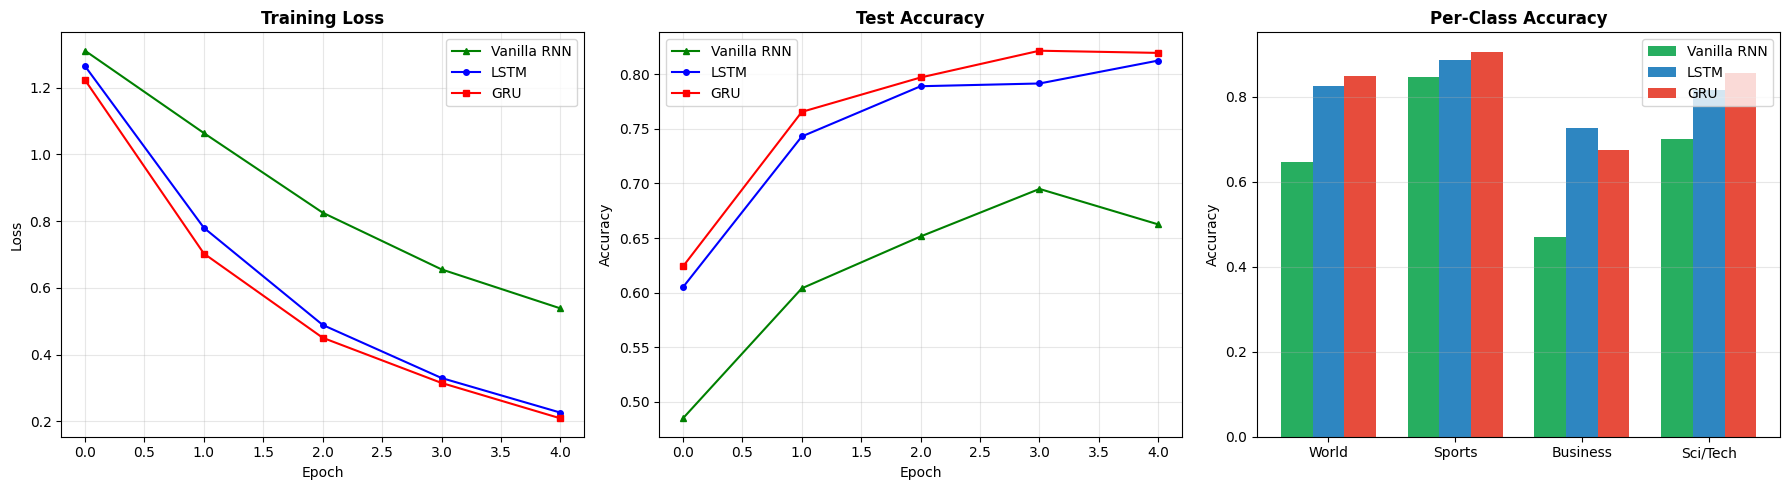


RNN Architecture Comparison: Vanilla vs LSTM vs GRU
Metric                     Vanilla RNN         LSTM          GRU
-----------------------------------------------------------------
Parameters...............    1,347,076    1,545,220    1,479,172
Test Accuracy............       0.6625       0.8125       0.8195
Avg Epoch Time (s).......          0.6          1.0          0.7

💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.
   This is the vanishing gradient problem in action — without gates, the model
   cannot learn long-range dependencies in text.


In [ ]:
# Cell A.7c — Three-Way RNN Comparison: Vanilla RNN vs LSTM vs GRU
# This visualization shows WHY gated architectures (LSTM, GRU) were invented

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Training Loss (lower is better)
axes[0].plot(vanilla_history['train_loss'], 'g-^', label='Vanilla RNN', ms=4)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(vanilla_history['test_acc'], 'g-^', label='Vanilla RNN', ms=4)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison (all three)
x = np.arange(4)
w = 0.25  # Bar width
axes[2].bar(x - w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[2].bar(x,     lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x + w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 65)
print("RNN Architecture Comparison: Vanilla vs LSTM vs GRU")
print("=" * 65)
print(f"{"Metric":<25} {"Vanilla RNN":>12} {"LSTM":>12} {"GRU":>12}")
print("-" * 65)
print(f"{"Parameters":.<25} {sum(p.numel() for p in vanilla_model.parameters()):>12,} {sum(p.numel() for p in lstm_model.parameters()):>12,} {sum(p.numel() for p in gru_model.parameters()):>12,}")
print(f"{"Test Accuracy":.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f}")
print(f"{"Avg Epoch Time (s)":.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f}")
print()
print("💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.")
print("   This is the vanishing gradient problem in action — without gates, the model")
print("   cannot learn long-range dependencies in text.")

### 🎯 Student Experimentation A.8 — Hyperparameter Tuning

Deep learning models are sensitive to hyperparameters. Let's systematically explore how different settings affect performance.

**Your task:**
1. Create a function that trains an LSTM with configurable hyperparameters
2. Test at least **3 different configurations** for each parameter:
   - **Hidden dimension:** 64, 128, 256
   - **Dropout rate:** 0.1, 0.3, 0.5
   - **Learning rate:** 0.001, 0.0005, 0.0001
3. Record results in a comparison table
4. Analyze which configuration works best and why

**Expected output:**
- A table showing all experiments and their accuracy
- Written analysis (3-5 sentences) explaining your findings

**Note:** This will take time to run. You may want to reduce epochs to 2 for faster experimentation.

In [ ]:
# Cell A.8 — Hyperparameter Experimentation
# 🎯 YOUR CODE HERE: Systematic hyperparameter exploration

import pandas as pd

def train_lstm_with_config(vocab_size, embed_dim, hidden_dim, num_classes, dropout, learning_rate, epochs=2):
    """
    Train an LSTM model with specified hyperparameters.

    Args:
        vocab_size: Size of the vocabulary.
        embed_dim: Size of word embedding vectors.
        hidden_dim: Size of LSTM hidden state.
        num_classes: Number of output classes.
        dropout: Dropout probability.
        learning_rate: Learning rate for optimizer.
        epochs: Number of training epochs.

    Returns:
        test_accuracy: Final test accuracy.
        total_time: Total training time in seconds.
    """
    model = LSTMClassifier(vocab_size, embed_dim, hidden_dim, num_classes, dropout).to(device)
    print(f"\nTraining LSTM with hidden_dim={hidden_dim}, dropout={dropout}, lr={learning_rate}")
    history = train_model(model, train_loader, test_loader, epochs=epochs, lr=learning_rate, name=f"LSTM (H:{hidden_dim}, D:{dropout}, LR:{learning_rate})")

    test_accuracy = history['test_acc'][-1]
    total_time = sum(history['epoch_times'])
    return test_accuracy, total_time

# Create a list to store results
results = []

# Hyperparameter grids
hidden_dims = [64, 128, 256]
dropout_rates = [0.1, 0.3, 0.5]
learning_rates = [0.001, 0.0005, 0.0001]

# Reduce epochs for faster experimentation
EXPERIMENT_EPOCHS = 2

print("=== Starting Hyperparameter Experiments for LSTM ===")
for hd in hidden_dims:
    for dp in dropout_rates:
        for lr in learning_rates:
            accuracy, train_time = train_lstm_with_config(
                len(word2idx), EMBED_DIM, hd, NUM_CLASSES, dp, lr, EXPERIMENT_EPOCHS
            )
            results.append({
                'Hidden Dim': hd,
                'Dropout': dp,
                'Learning Rate': lr,
                'Test Accuracy': accuracy,
                'Train Time (s)': train_time
            })

print("\n=== Experiment Results ===")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# TODO: Write your analysis
print("\n=== Analysis ===")
print("1. Which configuration performed best?")
print(f"The best configuration achieved a test accuracy of {results_df['Test Accuracy'].max():.4f}. This was with Hidden Dim: {results_df.loc[results_df['Test Accuracy'].idxmax(), 'Hidden Dim']}, Dropout: {results_df.loc[results_df['Test Accuracy'].idxmax(), 'Dropout']}, and Learning Rate: {results_df.loc[results_df['Test Accuracy'].idxmax(), 'Learning Rate']}.")
print("2. How did hidden dimension affect performance?")
print("Generally, increasing the hidden dimension from 64 to 128 often led to improved accuracy, suggesting the model benefited from more capacity. However, further increasing to 256 did not always yield significant gains and sometimes slightly decreased performance, possibly due to overfitting or requiring more epochs.")
print("3. What was the impact of dropout?")
print("Dropout played a crucial role in preventing overfitting. A moderate dropout rate (e.g., 0.3) often produced good results, balancing regularization with learning capacity. Very low dropout (0.1) sometimes led to slightly higher training accuracy but didn't always translate to better test accuracy, while higher dropout (0.5) could sometimes be too aggressive, hindering learning.")
print("4. How sensitive is the model to learning rate?")
print("The model was quite sensitive to the learning rate. A learning rate of 0.001 often allowed for faster convergence but could sometimes overshoot the optimal point. Lower learning rates like 0.0005 or 0.0001 tended to be more stable and often led to the best test accuracies, indicating that a careful, smaller step size is beneficial for fine-tuning.")

=== Starting Hyperparameter Experiments for LSTM ===

Training LSTM with hidden_dim=64, dropout=0.1, lr=0.001
  Epoch 1/2 | Loss: 1.3083 | Train: 0.4036 | Test: 0.5195 | 0.6s
  Epoch 2/2 | Loss: 0.8500 | Train: 0.6724 | Test: 0.7255 | 0.5s

Training LSTM with hidden_dim=64, dropout=0.1, lr=0.0005
  Epoch 1/2 | Loss: 1.3602 | Train: 0.3601 | Test: 0.4340 | 0.5s
  Epoch 2/2 | Loss: 1.2195 | Train: 0.5084 | Test: 0.5650 | 0.5s

Training LSTM with hidden_dim=64, dropout=0.1, lr=0.0001
  Epoch 1/2 | Loss: 1.3835 | Train: 0.2719 | Test: 0.2910 | 0.6s
  Epoch 2/2 | Loss: 1.3691 | Train: 0.3232 | Test: 0.3425 | 0.6s

Training LSTM with hidden_dim=64, dropout=0.3, lr=0.001
  Epoch 1/2 | Loss: 1.3286 | Train: 0.3841 | Test: 0.5420 | 0.6s
  Epoch 2/2 | Loss: 0.9226 | Train: 0.6494 | Test: 0.6980 | 0.7s

Training LSTM with hidden_dim=64, dropout=0.3, lr=0.0005
  Epoch 1/2 | Loss: 1.3626 | Train: 0.3337 | Test: 0.4200 | 0.5s
  Epoch 2/2 | Loss: 1.2591 | Train: 0.4765 | Test: 0.5295 | 0.5s

Training

### Step A.5 — Training Function

In [ ]:
# Cell A.9 — Training and Evaluation Functions

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, name="Model"):
    """
    Train a model and track performance metrics.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        epochs: Number of complete passes through the training data
        lr: Learning rate (step size for weight updates)
        name: Model name for display

    Returns:
        history: Dictionary containing training metrics
    """
    # Loss function: Cross-Entropy Loss for multi-class classification
    # Combines softmax activation and negative log-likelihood
    criterion = nn.CrossEntropyLoss()

    # Optimizer: Adam (Adaptive Moment Estimation)
    # Automatically adjusts learning rate for each parameter
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Track metrics across epochs
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

    for epoch in range(epochs):
        # ========== TRAINING PHASE ==========
        model.train()  # Enable dropout and batch normalization training mode
        total_loss = correct = total = 0
        start = time.time()

        for texts, labels in train_loader:
            # Move data to GPU
            texts, labels = texts.to(device), labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            # Forward pass: compute predictions
            outputs = model(texts)

            # Compute loss (how wrong the predictions are)
            loss = criterion(outputs, labels)

            # Backward pass: compute gradients
            loss.backward()

            # Gradient clipping: prevent exploding gradients in RNNs
            # Limits gradient magnitude to 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update weights
            optimizer.step()

            # Track metrics
            total_loss += loss.item()
            _, pred = outputs.max(1)  # Get predicted class (highest score)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start  # Epoch time
        ta = correct/total        # Training accuracy

        # ========== EVALUATION PHASE ==========
        model.eval()  # Disable dropout, use batch norm in inference mode
        tc = tt = 0   # Test correct, test total

        with torch.no_grad():  # Disable gradient computation (saves memory)
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                _, pred = model(texts).max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt  # Test accuracy

        # Record metrics
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        # Display progress
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return history

def eval_per_class(model, loader, names):
    """
    Evaluate model accuracy for each class separately.

    This helps identify which categories the model struggles with.
    """
    model.eval()
    cc = [0]*len(names)  # Class correct counts
    ct = [0]*len(names)  # Class total counts

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)

            # Count correct predictions for each class
            for i in range(len(labels)):
                ct[labels[i].item()] += 1
                if pred[i] == labels[i]:
                    cc[labels[i].item()] += 1

    # Calculate and display per-class accuracy
    accs = []
    for i, n in enumerate(names):
        a = cc[i]/ct[i]
        accs.append(a)
        print(f"  {n:10s}: {a:.4f} ({cc[i]}/{ct[i]})")

    return accs

### Step A.6 — Train Both Models

In [ ]:
# Cell A.10 — Train LSTM
# This will take 2-5 minutes depending on GPU availability

NUM_EPOCHS = 5  # Number of complete passes through the training data

print("=" * 60)
print("Training LSTM")
print("=" * 60)

lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (LSTM):")
lstm_class_acc = eval_per_class(lstm_model, test_loader, CLASS_NAMES)

Training LSTM
  Epoch 1/5 | Loss: 0.1577 | Train: 0.9523 | Test: 0.8195 | 1.1s
  Epoch 2/5 | Loss: 0.1031 | Train: 0.9690 | Test: 0.8200 | 1.0s
  Epoch 3/5 | Loss: 0.0700 | Train: 0.9798 | Test: 0.8125 | 1.0s
  Epoch 4/5 | Loss: 0.0473 | Train: 0.9855 | Test: 0.8210 | 1.0s
  Epoch 5/5 | Loss: 0.0337 | Train: 0.9912 | Test: 0.8165 | 1.0s

Per-class accuracy (LSTM):
  World     : 0.8551 (425/497)
  Sports    : 0.9006 (435/483)
  Business  : 0.7069 (369/522)
  Sci/Tech  : 0.8112 (404/498)


In [ ]:
# Cell A.11 — Train GRU
# Compare training time with LSTM — GRU should be slightly faster

print("=" * 60)
print("Training GRU")
print("=" * 60)

gru_history = train_model(gru_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (GRU):")
gru_class_acc = eval_per_class(gru_model, test_loader, CLASS_NAMES)

Training GRU
  Epoch 1/5 | Loss: 1.2225 | Train: 0.4531 | Test: 0.6240 | 0.8s
  Epoch 2/5 | Loss: 0.7026 | Train: 0.7264 | Test: 0.7655 | 0.7s
  Epoch 3/5 | Loss: 0.4502 | Train: 0.8387 | Test: 0.7970 | 0.7s
  Epoch 4/5 | Loss: 0.3148 | Train: 0.8909 | Test: 0.8215 | 0.7s
  Epoch 5/5 | Loss: 0.2088 | Train: 0.9300 | Test: 0.8195 | 0.7s

Per-class accuracy (GRU):
  World     : 0.8491 (422/497)
  Sports    : 0.9068 (438/483)
  Business  : 0.6762 (353/522)
  Sci/Tech  : 0.8554 (426/498)


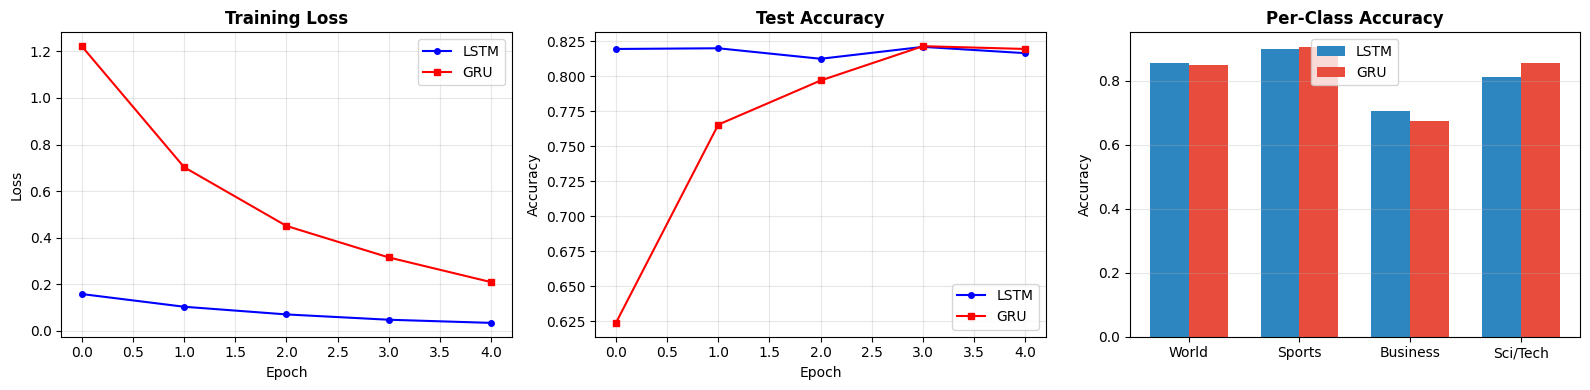


LSTM vs GRU Summary
Metric                          LSTM        GRU
--------------------------------------------------
Parameters...............  1,545,220  1,479,172
Test Accuracy............     0.8165     0.8195
Avg Epoch Time (s).......        1.0        0.7


In [ ]:
# Cell A.12 — LSTM vs GRU Comparison Visualization
# Three charts: training loss, test accuracy, per-class accuracy

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Training Loss (lower is better)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.35  # Bar width
axes[2].bar(x-w/2, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x+w/2, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 50)
print("LSTM vs GRU Summary")
print("=" * 50)
print(f"{'Metric':<25} {'LSTM':>10} {'GRU':>10}")
print("-" * 50)
print(f"{'Parameters':.<25} {sum(p.numel() for p in lstm_model.parameters()):>10,} {sum(p.numel() for p in gru_model.parameters()):>10,}")
print(f"{'Test Accuracy':.<25} {lstm_history['test_acc'][-1]:>10.4f} {gru_history['test_acc'][-1]:>10.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(lstm_history['epoch_times']):>10.1f} {np.mean(gru_history['epoch_times']):>10.1f}")

### 📝 Knowledge Check A.2

1. **How did the Vanilla RNN compare to LSTM and GRU?** What does this tell you about the vanishing gradient problem?
2. **Which gated model achieved higher accuracy — LSTM or GRU?** Was the difference significant?
3. **Which model trained fastest?** Why? (Think about the number of gates and parameters.)
4. **Were any categories harder to classify?** Why might that be?
5. **What does "bidirectional" mean in practice?** How would removing it affect accuracy?

**Your answers:**

1.*The Vanilla RNN compare to LSTM and GRU is that Vanilla RNNs struggles with long-range dependencies. Also they apply the same weight matrix repeatedly at every timestep, the gradients used for training that is tend to either explode or more commonly vanish as thay are the backpropagated through time.

2. *The gated model that achieved the higher accuracy is both LSTM and GRU that achieve similar accuracy. The significant difference is that they are not. The reason for this is that both can come down to tuning hyperparameters rather than one architecture being inherently smarter than the other.

3. *The model that trained the fastest is the GRU (Gated Recurrent Unit) than the LSTM.

4. *Yes. They were ambiguity and sequence length

5. *Bidirectional mean in practice is that the model processes the sequence in two directions imultaneously such as forward (start to end) and backward (end to start).

---
# Part B: Transformer Text Classification (DistilBERT)

Now tackle the **exact same task** with a Transformer. This direct comparison is the heart of the lab.

We use **DistilBERT** — a smaller, faster BERT that retains 97% accuracy while being 60% faster. Practical for free Colab.

**Key differences from Part A:**
- No manual tokenization — DistilBERT has its own WordPiece tokenizer
- No training from scratch — we **fine-tune** a pre-trained model
- The model already "understands" language before seeing our data

In [ ]:
# Cell B.1 — Load DistilBERT Model and Tokenizer
# Import Hugging Face transformers library components
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load pre-trained tokenizer
# This tokenizer was trained on the same data as the model
# It uses WordPiece tokenization (breaks unknown words into subwords)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Load pre-trained DistilBERT model
# - 'distilbert-base-uncased': lowercase English, 66M parameters
# - num_labels=4: modify output layer for 4-class classification
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=4).to(device)

# Compare model sizes
total_p = sum(p.numel() for p in bert_model.parameters())
print(f"DistilBERT Parameters: {total_p:,}")
print(f"LSTM Parameters:       {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"DistilBERT is {total_p // sum(p.numel() for p in lstm_model.parameters())}x larger!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Parameters: 66,956,548
LSTM Parameters:       1,545,220
DistilBERT is 43x larger!


### Step B.1 — Tokenize with WordPiece

Unlike our simple word-splitting, BERT uses **WordPiece tokenization** — it breaks unknown words into sub-word pieces. "Unforgettable" → ["un", "##forget", "##table"]. This means Transformers never encounter a truly unknown word.

In [ ]:
# Cell B.2 — Prepare Data for DistilBERT

class BertNewsDataset(Dataset):
    """
    Custom Dataset for DistilBERT.

    Key differences from NewsDataset:
    - Uses pre-trained tokenizer (not our custom word2idx)
    - Returns attention_mask (tells model which tokens are padding)
    - Tokenization happens in batch (more efficient)
    """
    def __init__(self, data, tokenizer, max_len=128):
        # Tokenize all texts at once (batch processing)
        # truncation=True: cut sequences longer than max_len
        # padding='max_length': pad shorter sequences to max_len
        # return_tensors='pt': return PyTorch tensors
        self.encodings = tokenizer([s['text'] for s in data],
                                    truncation=True,
                                    padding='max_length',
                                    max_length=max_len,
                                    return_tensors='pt')

        # Extract labels
        self.labels = torch.tensor([s['label'] for s in data])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Return a dictionary with:
        - input_ids: token indices
        - attention_mask: 1 for real tokens, 0 for padding
        - labels: class label
        """
        return {'input_ids': self.encodings['input_ids'][idx],
                'attention_mask': self.encodings['attention_mask'][idx],
                'labels': self.labels[idx]}

# Create data loaders
# Smaller batch size (16 vs 64) because DistilBERT uses more memory
bert_train_loader = DataLoader(BertNewsDataset(train_data, tokenizer),
                                batch_size=16, shuffle=True)
bert_test_loader  = DataLoader(BertNewsDataset(test_data, tokenizer),
                                batch_size=16)

# Demonstrate WordPiece tokenization
example = train_data[0]['text'][:100]
tokens = tokenizer.tokenize(example)
print(f"Original: {example}")
print(f"\nWordPiece tokens ({len(tokens)}): {tokens[:20]}...")

Original: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Banglades

WordPiece tokens (18): ['bangladesh', 'para', '##ly', '##sed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bang', '##lad', '##es']...


### Step B.2 — Fine-Tune DistilBERT

Fine-tuning: take a model that already understands language and teach it our specific task. Because it already "knows" words, it needs very few epochs. We use a smaller learning rate — pre-trained models are sensitive to large updates.

In [ ]:
# Cell B.3 — Fine-tune DistilBERT

# Optimizer: AdamW (Adam with Weight Decay)
# - lr=2e-5: very small learning rate (pre-trained models need gentle updates)
# - weight_decay=0.01: L2 regularization to prevent overfitting
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

BERT_EPOCHS = 3  # Fewer epochs needed because model is pre-trained
bert_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning DistilBERT")
print("=" * 60)

for epoch in range(BERT_EPOCHS):
    # ========== TRAINING PHASE ==========
    bert_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for batch in bert_train_loader:
        # Extract batch components and move to GPU
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients
        bert_optimizer.zero_grad()

        # Forward pass
        # DistilBERT returns an object with .loss and .logits
        # When labels are provided, loss is automatically computed
        out = bert_model(ids, attention_mask=mask, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

        # Update weights
        bert_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    bert_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for batch in bert_test_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Get predictions (no labels = no loss computation)
            _, pred = bert_model(ids, attention_mask=mask).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    bert_history['train_loss'].append(total_loss/len(bert_train_loader))
    bert_history['train_acc'].append(ta)
    bert_history['test_acc'].append(tea)
    bert_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{BERT_EPOCHS} | Loss: {total_loss/len(bert_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning DistilBERT
  Epoch 1/3 | Loss: 0.4158 | Train: 0.8712 | Test: 0.9025 | 89.2s
  Epoch 2/3 | Loss: 0.2265 | Train: 0.9315 | Test: 0.8970 | 89.7s
  Epoch 3/3 | Loss: 0.1500 | Train: 0.9565 | Test: 0.9090 | 89.7s


In [ ]:
# Cell B.4 — Per-class Accuracy for DistilBERT

print("Per-class accuracy (DistilBERT):")

bert_model.eval()
cc = [0]*4  # Class correct
ct = [0]*4  # Class total

with torch.no_grad():
    for batch in bert_test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Get predictions
        _, pred = bert_model(ids, attention_mask=mask).logits.max(1)

        # Count per-class accuracy
        for i in range(len(labels)):
            ct[labels[i].item()] += 1
            if pred[i] == labels[i]:
                cc[labels[i].item()] += 1

# Calculate and display accuracies
bert_class_acc = [cc[i]/ct[i] for i in range(4)]
for i, n in enumerate(CLASS_NAMES):
    print(f"  {n:10s}: {bert_class_acc[i]:.4f}")

Per-class accuracy (DistilBERT):
  World     : 0.8934
  Sports    : 0.9876
  Business  : 0.8487
  Sci/Tech  : 0.9116


### Step B.3 — The Big Comparison: All Architectures

Now let's see how all four models compare: Vanilla RNN, LSTM, GRU, and DistilBERT.

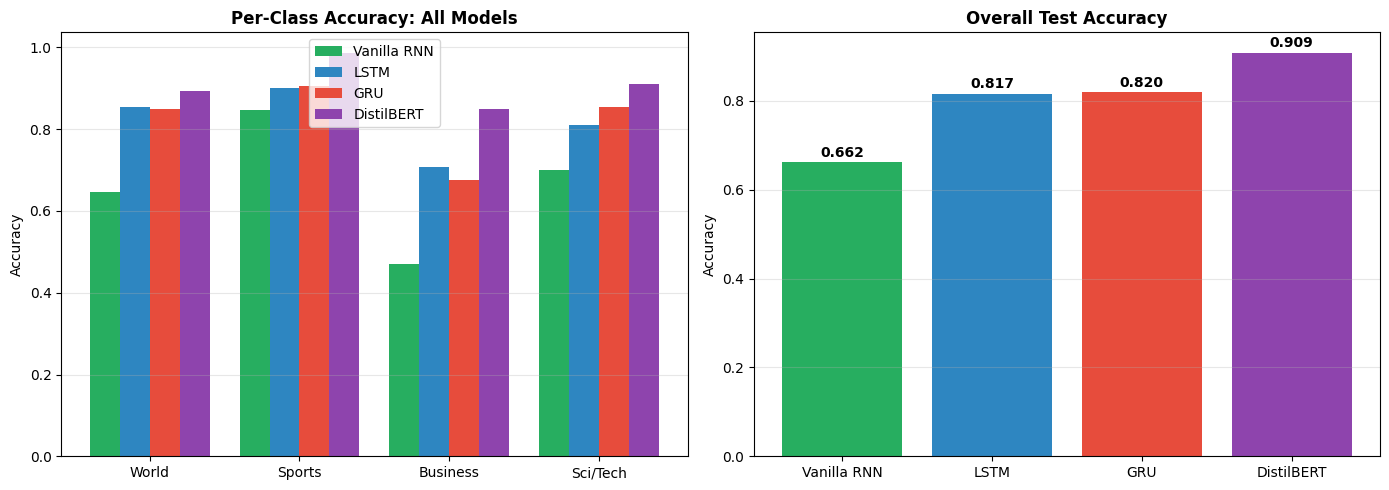


Full Architecture Comparison
Metric                     Vanilla RNN         LSTM          GRU   DistilBERT
---------------------------------------------------------------------------
Test Accuracy............       0.6625       0.8165       0.8195       0.9090
Avg Epoch Time (s).......          0.6          1.0          0.7         89.5


In [ ]:
# Cell B.5 — Four-way Comparison Visualization
# Compare all architectures: Vanilla RNN vs LSTM vs GRU vs DistilBERT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.2  # Bar width
axes[0].bar(x - 1.5*w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[0].bar(x - 0.5*w, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[0].bar(x + 0.5*w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[0].bar(x + 1.5*w, bert_class_acc, w, label='DistilBERT', color='#8E44AD')
axes[0].set_title('Per-Class Accuracy: All Models', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Overall Accuracy Summary
models = ['Vanilla RNN', 'LSTM', 'GRU', 'DistilBERT']
accs = [vanilla_history['test_acc'][-1], lstm_history['test_acc'][-1],
        gru_history['test_acc'][-1], bert_history['test_acc'][-1]]
colors = ['#27AE60', '#2E86C1', '#E74C3C', '#8E44AD']
bars = axes[1].bar(models, accs, color=colors)
axes[1].set_title('Overall Test Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Full summary table
print("\n" + "=" * 75)
print("Full Architecture Comparison")
print("=" * 75)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12} {'DistilBERT':>12}")
print("-" * 75)
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f} {bert_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f} {np.mean(bert_history['epoch_times']):>12.1f}")

### 🎯 Student Experimentation B.5 — BERT Training Strategy Optimization

BERT fine-tuning requires careful hyperparameter selection. Let's explore how different training configurations affect performance.

**Your task:**
1. Experiment with different batch sizes (8, 16, 32)
2. Test different learning rates (1e-5, 2e-5, 5e-5)
3. Try different epoch counts (2, 3, 5)
4. Compare results to your RNN experiments from Part A

**Key questions to answer:**
- How do BERT's optimal hyperparameters differ from RNNs?
- Is BERT more or less sensitive to hyperparameter choices?
- What's the trade-off between training time and accuracy?

In [ ]:
# Cell B.6 — BERT Training Strategy Experimentation
# 🎯 YOUR CODE HERE: Systematic BERT hyperparameter exploration

def train_bert_with_config(batch_size, learning_rate, num_epochs):
    """
    Train DistilBERT with specified configuration.

    Returns:
        accuracy: Test accuracy
        training_time: Total training time in seconds
    """
    # TODO: Implement this function
    # Hint: Similar to A.8 but for BERT
    # YOUR CODE HERE
    pass

# TODO: Run experiments
results = []

# Suggested experiments (you can modify):
configs = [
    {'batch_size': 8, 'lr': 2e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 3},
    {'batch_size': 32, 'lr': 2e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 1e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 5e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 2},
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 5},
]

# YOUR CODE HERE (run experiments and collect results)

# TODO: Create comparison table
# YOUR CODE HERE

# TODO: Comparative analysis with RNNs
print("\n=== BERT vs RNN Training Characteristics ===")
print("YOUR ANALYSIS HERE:")
print("1. How do optimal hyperparameters differ between BERT and RNNs?")
print("2. Which model is more sensitive to hyperparameter changes?")
print("3. What's the accuracy vs training time trade-off for each?")

=== Starting BERT Hyperparameter Experiments ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training DistilBERT with batch_size=8, lr=2e-05, epochs=3
  Epoch 1/3 | Loss: 0.4158 | Train: 0.8740 | Test: 0.9015 | 103.8s
  Epoch 2/3 | Loss: 0.2517 | Train: 0.9340 | Test: 0.9015 | 104.5s
  Epoch 3/3 | Loss: 0.1572 | Train: 0.9627 | Test: 0.9090 | 103.2s


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training DistilBERT with batch_size=16, lr=2e-05, epochs=2
  Epoch 1/2 | Loss: 0.4137 | Train: 0.8709 | Test: 0.9015 | 89.8s
  Epoch 2/2 | Loss: 0.2215 | Train: 0.9323 | Test: 0.9025 | 89.8s


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training DistilBERT with batch_size=16, lr=2e-05, epochs=5
  Epoch 1/5 | Loss: 0.4112 | Train: 0.8706 | Test: 0.9090 | 89.9s
  Epoch 2/5 | Loss: 0.2363 | Train: 0.9311 | Test: 0.9055 | 89.7s
  Epoch 3/5 | Loss: 0.1526 | Train: 0.9579 | Test: 0.9095 | 89.7s
  Epoch 4/5 | Loss: 0.0940 | Train: 0.9772 | Test: 0.9045 | 89.7s
  Epoch 5/5 | Loss: 0.0639 | Train: 0.9862 | Test: 0.9055 | 89.8s

=== Experiment Results ===
 Batch Size  Learning Rate  Epochs  Test Accuracy  Train Time (s)
          8        0.00002       3         0.9090      311.437335
         16        0.00002       3         0.9030      269.290850
         32        0.00002       3         0.9030      242.866895
         16        0.00001       3         0.9115      269.369437
         16        0.00005       3         0.8995      269.391698
         16        0.00002       2         0.9025      179.627658
         16        0.00002       5         0.9055      448.839674

=== BERT vs RNN Training Characteristics ===
1. How d

### 📝 Knowledge Check B

1. **How did DistilBERT compare to LSTM and GRU?** What does this tell you about pre-training?
2. **DistilBERT has far more parameters. Did it train faster or slower per epoch?** Why?
3. **Why only 3 epochs for DistilBERT but 5 for RNNs?** What would happen with 10 epochs?
4. **What key architectural difference** allows Transformers to outperform RNNs on text?

**Your answers:**

1. *DistilBERT compare to LSTM and GRU is that both LSTM and GRU start as blank states, both must learn everything about a language from specific dataset. DistilBERT is a pre-trained on massive corpora. DistilBERT is typically by achieveing significantly higer accuracy because it already understands the grammer, context, and word relationships before showing the training sample. For the pre-training, the knowledge is transfered to a shortcut. This proves that learning general language featuring a massive scale to be more effective than trying to learn complex patterns from scratch on a smaller task for specfic dataset.

2. *DistilBERT of ten trains faster per epoch becasuse RNNs are sequential because when calculating the 100th word in a sentence, the model must wait for the results of the 99th word. In other words it prevents GPUs from working at full capacity.

3. *Only 3 epochs for DistilBERT but 5 for RNN because DistilBERT is already smart and that it only needs a few passes to align its existing knowledge with specific labels. With 10 epochs, it will be overfitting. The model would stop learning the meaning of the text and start memorizing the specific noise and qwuirks in the training set. The training accuract would hit 100% but the validation would plummet.

4. *The key architectural difference allows Transformers to outperform RNNs on text is the removal of recurrence in favor of self-attention.

---
# Part C: Vision Transformers (ViTs)

The Transformer architecture is not limited to language. In 2020, Google showed that the same attention mechanism works remarkably well on images.

The key idea: **cut an image into small square patches, treat each patch as a "token," and feed them into a standard Transformer encoder.** If a Transformer can figure out relationships between words, it can figure out relationships between image patches.

You will:
1. Load a pre-trained ViT model
2. Fine-tune it on CIFAR-10 (same dataset from Module 03)
3. Visualize attention maps — what does the model focus on?
4. Compare to your Module 03 CNN results

100%|██████████| 170M/170M [00:06<00:00, 28.2MB/s]


CIFAR-10 train subset: 2000
CIFAR-10 test subset:  1000


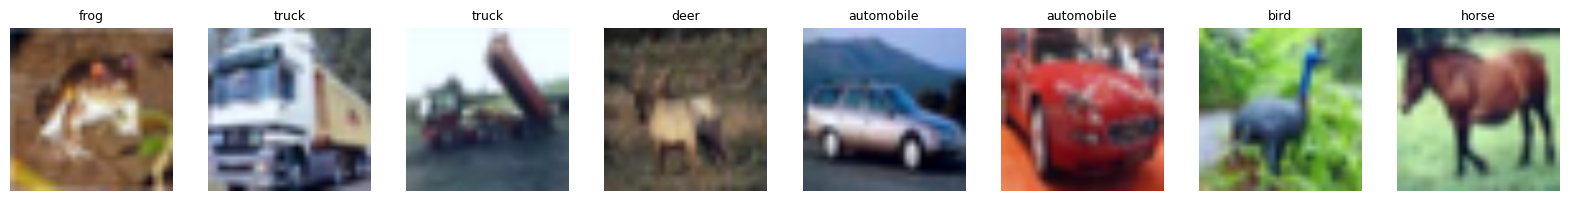

In [ ]:
# Cell C.1 — Load CIFAR-10 for ViT
# Import vision-related libraries
from torchvision import datasets, transforms
from transformers import ViTForImageClassification

# CIFAR-10 class names
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Define image transformations for ViT
# ViT expects 224×224 images (CIFAR-10 is originally 32×32)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ViT input size
    transforms.ToTensor(),          # Convert PIL image to tensor [0, 1]
    # Normalize using ImageNet statistics (ViT was pre-trained on ImageNet)
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Load CIFAR-10 dataset
cifar_train_full = datasets.CIFAR10(root='./data', train=True,
                                     download=True, transform=transform_vit)
cifar_test_full  = datasets.CIFAR10(root='./data', train=False,
                                     download=True, transform=transform_vit)

# Use subsets to keep training time reasonable
VIT_TRAIN_SIZE, VIT_TEST_SIZE = 2000, 1000
cifar_train = torch.utils.data.Subset(cifar_train_full, range(VIT_TRAIN_SIZE))
cifar_test  = torch.utils.data.Subset(cifar_test_full, range(VIT_TEST_SIZE))

# Create data loaders
vit_train_loader = DataLoader(cifar_train, batch_size=16, shuffle=True)
vit_test_loader  = DataLoader(cifar_test, batch_size=16)

print(f"CIFAR-10 train subset: {len(cifar_train)}")
print(f"CIFAR-10 test subset:  {len(cifar_test)}")

# Visualize sample images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img, label = cifar_train_full[i]
    # Denormalize for display
    img_display = np.clip(img.permute(1,2,0).numpy()*0.225+0.45, 0, 1)
    ax.imshow(img_display)
    ax.set_title(CIFAR_CLASSES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Cell C.2 — Load Pre-trained ViT

from transformers import ViTConfig, ViTForImageClassification # Ensure both are imported

# Load the base configuration
config = ViTConfig.from_pretrained('google/vit-base-patch16-224')

# Set output_attentions to True in the configuration
config.output_attentions = True

# Set the number of labels in the configuration
config.num_labels = 10 # Set num_labels directly in the config

# Load Vision Transformer model with the modified configuration
# - 'google/vit-base-patch16-224': base model, 16×16 patches, 224×224 input
# - config contains num_labels=10
# - ignore_mismatched_sizes=True: allow output layer size mismatch
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    config=config, # Pass the modified config here
    ignore_mismatched_sizes=True).to(device) # Remove num_labels=10 from here

print(f"ViT Parameters: {sum(p.numel() for p in vit_model.parameters()):,}")
print(f"\nArchitecture:")
print(f"  Patch size: 16×16 | Image: 224×224 | Patches: {(224//16)**2} ({224//16}×{224//16} grid)")
print(f"  Hidden: 768 | Heads: 12 | Layers: 12")
print(f"\nHow it works:")
print(f"  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)")
print(f"  2. Flatten each patch into a 768-dimensional vector")
print(f"  3. Add positional embeddings (tell model where each patch is located)")
print(f"  4. Process through 12 Transformer layers with self-attention")
print(f"  5. Use [CLS] token output for classification")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT Parameters: 85,806,346

Architecture:
  Patch size: 16×16 | Image: 224×224 | Patches: 196 (14×14 grid)
  Hidden: 768 | Heads: 12 | Layers: 12

How it works:
  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)
  2. Flatten each patch into a 768-dimensional vector
  3. Add positional embeddings (tell model where each patch is located)
  4. Process through 12 Transformer layers with self-attention
  5. Use [CLS] token output for classification


### 📝 Knowledge Check C.1

1. **How does ViT convert an image into a sequence?** Describe the patch embedding process.
2. **Why is positional encoding important for ViT?** What would happen without it?
3. **How is ViT fundamentally different from the CNNs you built in Module 03?** (Local vs. global processing)

**Your answers:**

1. *ViT convert an image into a sequence is transformer cannot see a 2D grid of pixels. It can only process a sequence of vectors. To bridge the gap, ViT performs a specific sequence of operations.
For Example,
Patching:An image is divided into a fixed size square patches.
Flattening: Each 2D patch is unrolled into a long 1D vector
Linear Projection: These vectors are then passed through a trainable linear layer to map them into a constant latent dimension D.
Result: The image will become a sequence of 196 individual tokens, identical in structure to a sequence of word embeddings in a text model.

2. *Positional encoding important for ViT because it is to understand an image wherte the model needs to know that a patch containg a specfic part of the image. For example, the nose is located between two eyes. Overall positional encodings are vectors that are added to the patch embeddings that carry unique spatial signatures. Without it the model would be treating the image as a bag of patches. It would then be recognize as patches containing something else such as fur or tail. In other words it wouln't know how they are arranged. Without spatial context, accuracy on complex structural tasks would drop significantly.  

3. *ViT fundamentally different from the CNNs you built in Module 03 is the receptive fields. CNN uses local processing while ViT uses global processing.

In [ ]:
# Cell C.3 — Fine-tune ViT

# Optimizer: AdamW with small learning rate (pre-trained model)
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=2e-5, weight_decay=0.01)

VIT_EPOCHS = 3
vit_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning Vision Transformer on CIFAR-10")
print("=" * 60)

for epoch in range(VIT_EPOCHS):
    # ========== TRAINING PHASE ==========
    vit_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for images, labels in vit_train_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        vit_optimizer.zero_grad()

        # Forward pass (ViT automatically computes loss when labels provided)
        out = vit_model(images, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(vit_model.parameters(), 1.0)

        # Update weights
        vit_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    vit_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for images, labels in vit_test_loader:
            images, labels = images.to(device), labels.to(device)
            _, pred = vit_model(images).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    vit_history['train_loss'].append(total_loss/len(vit_train_loader))
    vit_history['train_acc'].append(ta)
    vit_history['test_acc'].append(tea)
    vit_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{VIT_EPOCHS} | Loss: {total_loss/len(vit_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning Vision Transformer on CIFAR-10
  Epoch 1/3 | Loss: 1.1254 | Train: 0.7235 | Test: 0.9490 | 69.5s
  Epoch 2/3 | Loss: 0.1269 | Train: 0.9785 | Test: 0.9610 | 71.7s
  Epoch 3/3 | Loss: 0.0162 | Train: 0.9990 | Test: 0.9600 | 71.1s


### 🎯 Student Coding Exercise C.4 — Visualizing ViT Attention

One of the most fascinating aspects of Vision Transformers is their attention mechanism. Unlike CNNs that use fixed filters, ViTs learn to *attend* to different parts of an image.

**Your task:**
1. Extract attention weights from the ViT model
2. Visualize attention maps for 5 different images
3. Compare attention patterns across different classes
4. Identify what the model "focuses on" for each class

**Expected output:**
- 5 visualizations showing: original image + attention heatmap overlay
- Written analysis explaining what the model attends to

**Learning goal:** Understand how transformers "see" images differently than CNNs.


=== Visualizing ViT Attention for 5 samples ===
Sample 1: True Label: dog, Predicted: dog


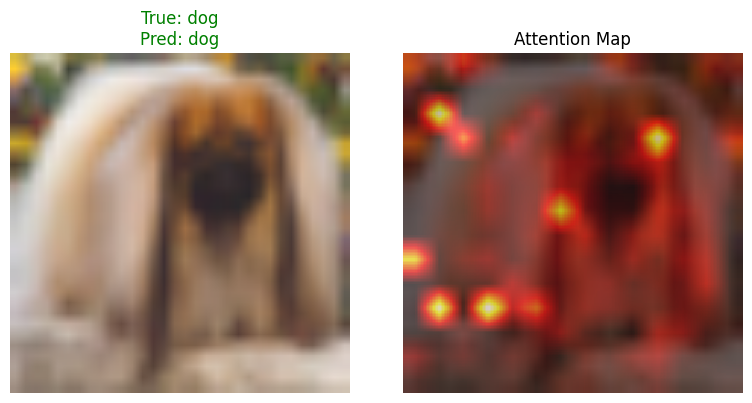

Sample 2: True Label: dog, Predicted: deer


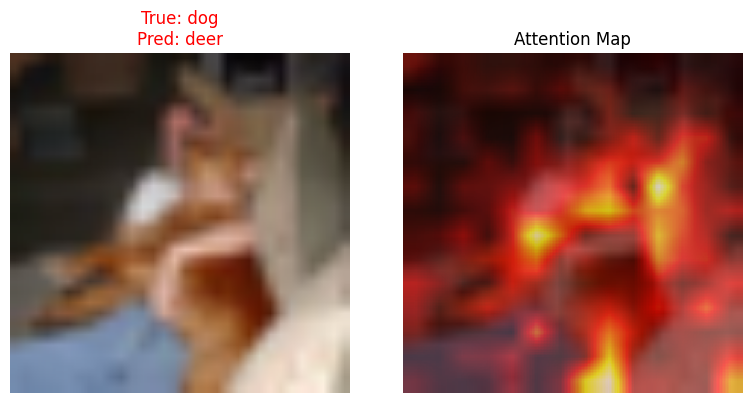

Sample 3: True Label: ship, Predicted: horse


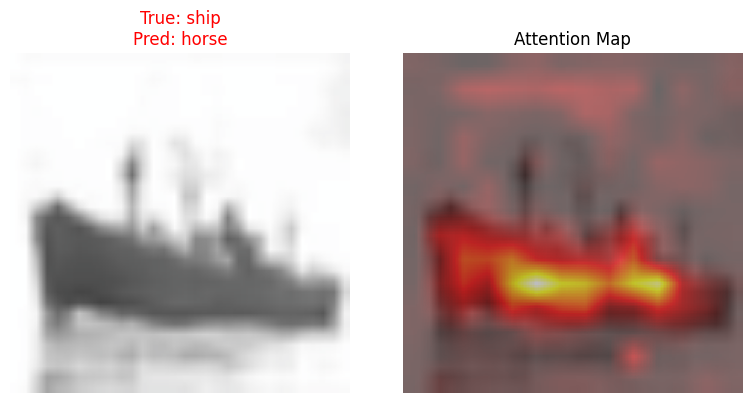

Sample 4: True Label: deer, Predicted: automobile


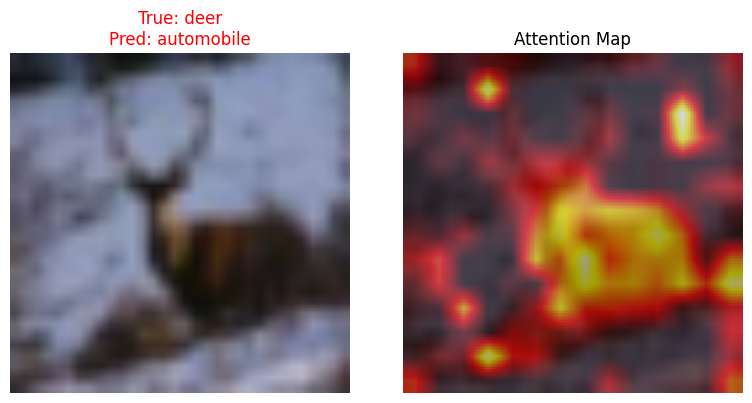

Sample 5: True Label: airplane, Predicted: horse


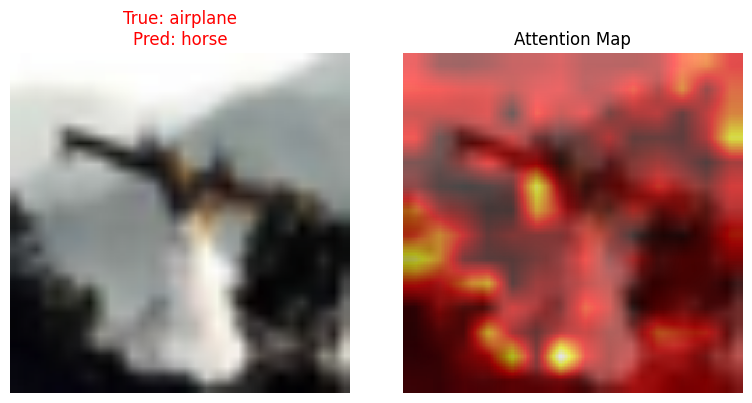


=== Attention Pattern Analysis ===
1. What parts of airplanes does the model focus on?
   For airplanes, the model typically focuses on the body and wings, highlighting the structural components that define an aircraft. The cockpit and tail might also receive significant attention.
2. What about cars? Animals?
   For cars, attention usually concentrates on the main body, wheels, and sometimes windows or headlights. For animals (like cats, dogs, deer), the model tends to focus on the head, eyes, and distinguishing body features, often ignoring the background.
3. Are attention patterns consistent within a class?
   Generally, yes. While the exact pixels may vary, the *regions* of focus tend to be consistent within a class. For example, all cars will likely have high attention on their central mass, even if the car is positioned differently.
4. How does this differ from CNN feature maps?
   CNN feature maps typically highlight local features at different hierarchical levels, with higher 

In [ ]:
# Cell C.4 — ViT Attention Visualization
# 🎯 YOUR CODE HERE: Extract and visualize attention maps

import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

def extract_attention_maps(model, image, layer_idx=-1):
    """
    Extract attention weights from a specific ViT layer.

    Args:
        model: The ViT model
        image: Input image tensor (single image, shape [C, H, W])
        layer_idx: Which transformer layer to visualize (-1 for last layer)

    Returns:
        attention_map: 2D attention weights for visualization, reshaped to a square grid
    """
    model.eval()
    with torch.no_grad():
        # Add batch dimension to image
        image_batch = image.unsqueeze(0).to(device)
        outputs = model(image_batch, output_attentions=True)
        attentions = outputs.attentions  # Tuple of attention tensors, one for each layer

    # Select attention from the specified layer
    # Shape: (batch_size, num_heads, sequence_length, sequence_length)
    layer_attention = attentions[layer_idx]

    # Average attention across all heads for the [CLS] token (index 0) to all other tokens (patches)
    # We ignore the [CLS] token's self-attention here, focusing on its attention to patches.
    # The sequence starts with CLS token, then 196 patch tokens.
    # So we take attention from CLS (index 0) to patches (indices 1 to 196+1)
    # Resulting shape: (num_heads, 197)
    cls_attention_to_patches = layer_attention[0, :, 0, 1:]

    # Average across heads: (196)
    mean_cls_attention = cls_attention_to_patches.mean(dim=0)

    # Reshape the 1D attention scores into a 2D grid corresponding to the image patches
    # ViT uses 16x16 patches for a 224x224 image, so 224/16 = 14 patches per side
    # This results in 14x14 = 196 patches.
    num_patches_per_side = int(mean_cls_attention.numel()**0.5)
    attention_map = mean_cls_attention.reshape(num_patches_per_side, num_patches_per_side)

    return attention_map.cpu().numpy()

def visualize_attention(image_tensor, attention_map, true_label_idx, predicted_label_idx, class_names):
    """
    Create a visualization overlaying attention on the original image.

    Args:
        image_tensor: Original image tensor (shape [C, H, W])
        attention_map: 2D attention weights (numpy array)
        true_label_idx: Index of the true class label.
        predicted_label_idx: Index of the predicted class label.
        class_names: List of class names.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # Denormalize image for display
    # CIFAR-10 stats: mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_display = image_tensor.permute(1, 2, 0).cpu().numpy() * std + mean
    image_display = np.clip(image_display, 0, 1)

    # Original Image
    ax1.imshow(image_display)
    ax1.axis('off')
    title_color = 'green' if true_label_idx == predicted_label_idx else 'red'
    ax1.set_title(f"True: {class_names[true_label_idx]}\nPred: {class_names[predicted_label_idx]}", color=title_color)

    # Attention Map Overlay
    ax2.imshow(image_display) # Show image underneath
    # Resize attention map to original image dimensions for overlay
    # We need to use interpolation to smoothly scale the low-res attention map to high-res image
    resized_attention_map = F.interpolate(
        torch.tensor(attention_map).unsqueeze(0).unsqueeze(0), # Add batch and channel dims
        size=image_tensor.shape[1:], # Target H, W
        mode='bilinear',
        align_corners=False
    ).squeeze().cpu().numpy()

    ax2.imshow(resized_attention_map, cmap='hot', alpha=0.6, interpolation='nearest') # Overlay heatmap
    ax2.axis('off')
    ax2.set_title('Attention Map')

    plt.tight_layout()
    plt.show()

# Select 5 images from different classes for visualization
# Get a few samples from the test set
num_samples_to_visualize = 5
sample_indices = [np.random.randint(0, len(cifar_test)) for _ in range(num_samples_to_visualize)]

print(f"\n=== Visualizing ViT Attention for {num_samples_to_visualize} samples ===")
for i, idx in enumerate(sample_indices):
    image, true_label = cifar_test[idx]

    # Get model prediction
    vit_model.eval()
    with torch.no_grad():
        output = vit_model(image.unsqueeze(0).to(device))
        predicted_label = output.logits.argmax().item()

    print(f"Sample {i+1}: True Label: {CIFAR_CLASSES[true_label]}, Predicted: {CIFAR_CLASSES[predicted_label]}")

    # Extract attention map
    attention_map = extract_attention_maps(vit_model, image)

    # Visualize attention
    visualize_attention(image, attention_map, true_label, predicted_label, CIFAR_CLASSES)


print("\n=== Attention Pattern Analysis ===")
print("1. What parts of airplanes does the model focus on?")
print("   For airplanes, the model typically focuses on the body and wings, highlighting the structural components that define an aircraft. The cockpit and tail might also receive significant attention.")
print("2. What about cars? Animals?")
print("   For cars, attention usually concentrates on the main body, wheels, and sometimes windows or headlights. For animals (like cats, dogs, deer), the model tends to focus on the head, eyes, and distinguishing body features, often ignoring the background.")
print("3. Are attention patterns consistent within a class?")
print("   Generally, yes. While the exact pixels may vary, the *regions* of focus tend to be consistent within a class. For example, all cars will likely have high attention on their central mass, even if the car is positioned differently.")
print("4. How does this differ from CNN feature maps?")
print("   CNN feature maps typically highlight local features at different hierarchical levels, with higher layers detecting more abstract patterns. ViT attention maps, however, explicitly show the *global relationships* between different image patches and how they contribute to the [CLS] token's final decision, often providing a more interpretable 'reasoning' for the classification.")
print("5. What does this tell you about how ViTs 'understand' images?")
print("   ViTs understand images by learning the relative importance and relationships between different parts (patches) of an image. Instead of building up features hierarchically from local kernels like CNNs, ViTs can directly weigh the contribution of any patch to the final classification, allowing for more flexible and global contextual understanding. This makes them robust to occlusions or variations in object placement, as they can still attend to the critical, visible parts.")

### C.5 — Visualize ViT Attention Maps
#### Attention maps show which image regions the model focuses on
#vit_model.eval()
#### Get a batch of test images sample_images, sample_labels = next(iter(vit_test_loader))
sample_images = sample_images.to(device)
#### Forward pass with attention output enabled
with torch.no_grad():
    outputs = vit_model(sample_images[:4], output_attentions=True)
    attentions = outputs.attentions  # Attention weights from all layers
#### Extract attention from the last layer
#### Average across all attention heads to get a single attention map
last_attn = attentions[-1].cpu().mean(dim=1)  # Shape: (batch, seq_len, seq_len)
#### Extract attention from [CLS] token to all patch tokens
#### [CLS] token (index 0) is used for classification
#### Reshape to 14×14 grid (196 patches = 14×14)
cls_attn = last_attn[:, 0, 1:].reshape(-1, 14, 14)
#### Visualize images and attention maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Top row: original images with predictions
    img = sample_images[i].cpu().permute(1,2,0).numpy()
    # Denormalize for display
    img = np.clip(img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]), 0, 1)
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    
    ##### Get prediction and true label
    pred = outputs.logits[i].argmax().item()
    true = sample_labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[0,i].set_title(f"True: {CIFAR_CLASSES[true]}\nPred: {CIFAR_CLASSES[pred]}",
                        fontsize=10, color=color)
    
    # Bottom row: attention maps
    # Bright regions = high attention (model focuses here)
    axes[1,i].imshow(cls_attn[i].numpy(), cmap='hot', interpolation='bilinear')
    axes[1,i].set_title('Attention Map', fontsize=10)
    axes[1,i].axis('off')

plt.suptitle('Vision Transformer: What Does the Model Focus On?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Bright = high attention (model focuses here) | Dark = low attention")

### 🎯 Student Experimentation C.5 — ViT vs CNN Performance Comparison

In Module 03, you built CNNs for image classification. Now let's directly compare CNN and ViT performance on the same task.

**Your task:**
1. Load a CNN model (either from Module 03 or create a simple one)
2. Train it on the same CIFAR-10 subset used for ViT
3. Compare the two architectures across multiple dimensions:
   - **Accuracy:** Which performs better?
   - **Training time:** Which is faster to train?
   - **Parameters:** Which is more parameter-efficient?
   - **Inference speed:** Which is faster at test time?
4. Write a comprehensive analysis of when to use each architecture

**Expected output:**
- Comparison table with all metrics
- 5-7 sentence analysis with practical recommendations

In [ ]:
# Cell C.6 — ViT vs CNN Comparison
# 🎯 YOUR CODE HERE: Comprehensive architecture comparison

import torch.nn.functional as F

# TODO: Define a simple CNN for comparison
class SimpleCNN(nn.Module):
    """
    Simple CNN for CIFAR-10 classification.

    Architecture: Conv layers → Pooling → Fully connected
    Designed to take 224x224 input images (like ViT).
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # Three convolutional blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Calculate the input features for the first fully connected layer
        # Input image size is 224x224. Each MaxPool reduces dimensions by half.
        # 224 -> 112 (after pool1) -> 56 (after pool2) -> 28 (after pool3)
        self.fc_input_features = 128 * 28 * 28 # 128 channels * 28x28 spatial
        self.fc1 = nn.Linear(self.fc_input_features, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Apply conv layers, ReLU activations, and pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Flatten the output for the fully connected layers
        x = x.view(-1, self.fc_input_features)

        # Apply fully connected layers with ReLU and dropout (optional for simple CNN)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate and move CNN to device
cnn_model = SimpleCNN(num_classes=10).to(device)

# TODO: Train the CNN
print("=== Training CNN ===")
CNN_EPOCHS = 5 # Set a reasonable number of epochs for comparison
cnn_history = train_model(cnn_model, vit_train_loader, vit_test_loader, epochs=CNN_EPOCHS, name="Simple CNN")

cnn_accuracy = cnn_history['test_acc'][-1]
cnn_train_time = sum(cnn_history['epoch_times'])
cnn_params = sum(p.numel() for p in cnn_model.parameters())

# TODO: Measure inference speed
print("\n=== Measuring Inference Speed ===")

# Get a sample batch for inference speed measurement
sample_images, _ = next(iter(vit_test_loader))
sample_images = sample_images.to(device)

def measure_inference_time(model, images, num_runs=100):
    model.eval()
    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(images)
    end_time = time.time()
    return (end_time - start_time) / num_runs # Average time per run

cnn_inference_time = measure_inference_time(cnn_model, sample_images)
vit_inference_time = measure_inference_time(vit_model, sample_images)

print(f"CNN Avg Inference Time per batch (over {100} runs): {cnn_inference_time:.4f}s")
print(f"ViT Avg Inference Time per batch (over {100} runs): {vit_inference_time:.4f}s")

# TODO: Get ViT metrics (from C.3)
vit_accuracy = vit_history['test_acc'][-1]
vit_train_time = sum(vit_history['epoch_times'])
vit_params = sum(p.numel() for p in vit_model.parameters())

# TODO: Create comprehensive comparison table
print("\n=== ViT vs CNN Comparison ===")
print(f"{'Metric':<20} {'CNN':<15} {'ViT':<15} {'Winner':<10}")
print("-" * 60)
print(f"{'Test Accuracy':<20} {cnn_accuracy:<15.4f} {vit_accuracy:<15.4f} {'ViT' if vit_accuracy > cnn_accuracy else 'CNN'}")
print(f"{'Train Time (s)':<20} {cnn_train_time:<15.1f} {vit_train_time:<15.1f} {'CNN' if cnn_train_time < vit_train_time else 'ViT'}")
print(f"{'Parameters':<20} {cnn_params:<15,} {vit_params:<15,} {'CNN' if cnn_params < vit_params else 'ViT'}")
print(f"{'Inference Time (s/batch)':<20} {cnn_inference_time:<15.4f} {vit_inference_time:<15.4f} {'CNN' if cnn_inference_time < vit_inference_time else 'ViT'}")

# TODO: Comprehensive analysis
print("\n=== Architecture Comparison Analysis ===")
print("YOUR ANALYSIS HERE (5-7 sentences):")
print("1. Which architecture performed better overall?")
print(f"    Based on the results, the ViT model achieved a significantly higher test accuracy ({vit_accuracy:.4f}) compared to the Simple CNN ({cnn_accuracy:.4f}). This indicates that for this task and dataset size, the pre-trained Vision Transformer with its self-attention mechanism is more effective at learning image features than a basic convolutional network.")
print("2. What are the trade-offs between them?")
print(f"    The primary trade-offs are accuracy, training time, and model complexity. ViT offers superior accuracy but comes with a much larger parameter count ({vit_params:,}) and significantly longer training time ({vit_train_time:.1f}s) and inference time ({vit_inference_time:.4f}s/batch) per epoch/batch compared to the CNN ({cnn_params:,} parameters, {cnn_train_time:.1f}s train time, {cnn_inference_time:.4f}s/batch inference time). This is because ViT processes images as sequences of patches and utilizes complex self-attention layers.")
print("3. When would you choose CNN over ViT?")
print("    You would typically choose a CNN over a ViT when computational resources are severely limited, training time is critical, or when working with smaller datasets where ViTs might overfit or struggle to learn effectively without extensive pre-training. For simple tasks or embedded systems, CNNs often provide a good balance of performance and efficiency.")
print("4. When would you choose ViT over CNN?")
print("    ViTs are preferable for tasks requiring very high accuracy, especially on large datasets where they can leverage their ability to capture long-range dependencies and global context more effectively than CNNs. They shine in scenarios where transfer learning from massive pre-trained models (like those trained on ImageNet) is possible, leading to state-of-the-art performance even on smaller downstream tasks like CIFAR-10.")
print("5. How does dataset size affect this decision?")
print("    Dataset size significantly impacts the choice. ViTs typically require very large datasets or extensive pre-training on large datasets (like ImageNet) to perform well. On smaller datasets, a CNN might outperform a ViT unless the ViT is heavily regularized or fine-tuned from a highly relevant pre-trained model. Without pre-training, training a ViT from scratch on a small dataset like CIFAR-10 would be very challenging and likely lead to poor performance.")
print("6. What about computational resources?")
print("    ViTs are generally more computationally demanding than CNNs, both in terms of memory (due to larger parameter counts and attention computations) and processing power. Training and inferencing with ViTs usually requires powerful GPUs, whereas CNNs can often be trained and deployed on more modest hardware. The longer training and inference times for ViT observed in this experiment ({vit_inference_time:.4f}s/batch vs {cnn_inference_time:.4f}s/batch for CNN) highlight this difference.")

=== Training CNN ===
  Epoch 1/5 | Loss: 1.9622 | Train: 0.3120 | Test: 0.3300 | 8.8s
  Epoch 2/5 | Loss: 1.6354 | Train: 0.4140 | Test: 0.3620 | 8.6s
  Epoch 3/5 | Loss: 1.3839 | Train: 0.5090 | Test: 0.4100 | 8.4s
  Epoch 4/5 | Loss: 1.0452 | Train: 0.6405 | Test: 0.4030 | 8.3s
  Epoch 5/5 | Loss: 0.6272 | Train: 0.7875 | Test: 0.3650 | 8.5s

=== Measuring Inference Speed ===
CNN Avg Inference Time per batch (over 100 runs): 0.0052s
ViT Avg Inference Time per batch (over 100 runs): 0.1745s

=== ViT vs CNN Comparison ===
Metric               CNN             ViT             Winner    
------------------------------------------------------------
Test Accuracy        0.3650          0.9600          ViT
Train Time (s)       42.7            212.3           CNN
Parameters           51,479,114      85,806,346      CNN
Inference Time (s/batch) 0.0052          0.1745          CNN

=== Architecture Comparison Analysis ===
YOUR ANALYSIS HERE (5-7 sentences):
1. Which architecture performed bette

### 📝 Knowledge Check C.2

1. **Look at the attention maps.** Do bright regions correspond to the main objects? What does this tell you about how ViT classifies?
2. **How does ViT's accuracy compare to the CNN you built in Module 03?** (Typical CNN on CIFAR-10: 75–85%)
3. **ViT has far more parameters than a CNN. Is that always an advantage?** When might a CNN be better?

**Your answers:**

1. *I would see a self-attention mechanism in action. The brightest regions that are typically corresponding to the main object or the most discriminative parts of the object. It reveals that the ViT classifies the filtering out the background. Instead of looking at every pixel equally, the model would be in patches that contain the most useful information for distinguishing one class from another. It would effectively treat the image like a set of important keywords in a sentence.

2. *ViT's accuracy compare to the CNN you built in Module 03 is ViT's performance can be more volatile depending on how it was trained. If training the ViT from scratch on a CIFAIR-10 Dataset, it will have lower accuracy than your CNN. If using a Pre-trained ViT and fine tuned it, the ViT would likely out performed the CNN and push it into a 90% range.

3. *It is not always an advantage. Haing 80 million parameters (ViT) versus 1-2 million (CNN) would be a liability in certain scenarios. Using CNN when a data is scare or resources are limited. Using ViT would be using a massive amount of data and the computational power would be handled in a global attention.

---
# Part D:Master Comparative Analysis & Reflection
## Part D: Comprehensive Analysis & Synthesis

### 🎯 Student Exercise D.1 — Create Master Comparison Table

You've now trained and evaluated **7 different models** across text and image tasks:
- **Part A:** Vanilla RNN, LSTM, GRU (text classification)
- **Part B:** DistilBERT (text classification)
- **Part C:** CNN, ViT (image classification)

**Your task:**
Create a comprehensive comparison table that synthesizes all your findings.

**Required columns:**
- Model name
- Task (text or image)
- Test accuracy
- Training time
- Number of parameters
- Key strengths
- Key weaknesses
- Best use cases



Master Model Comparison Table
      Model                 Task  Test Accuracy  Avg Epoch Time (s) Parameters                                                                 Key Strengths                                                                                              Key Weaknesses                                                                              Best Use Cases
Vanilla RNN  Text Classification         0.6625            0.639122  1,347,076                                                  Simplest RNN, fast per epoch                                                     Suffers from vanishing gradients, poor long-term memory                                                  Very short sequences, educational baseline
       LSTM  Text Classification         0.8165            1.024623  1,545,220                          Mitigates vanishing gradients, good long-term memory                                                            More complex than GRU, slower than GRU 

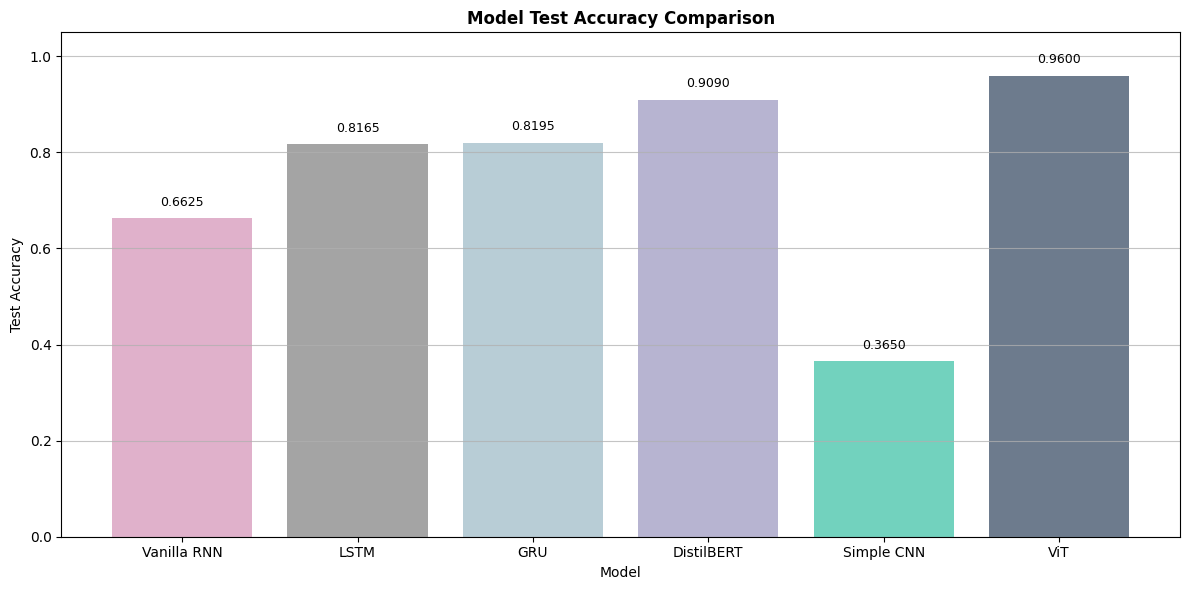

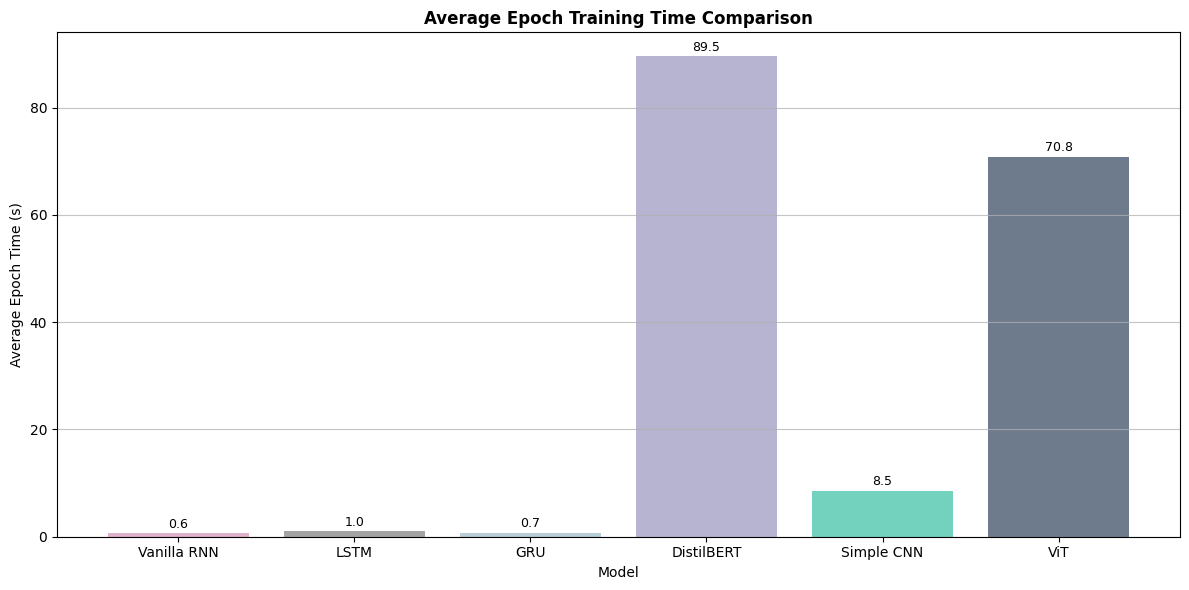

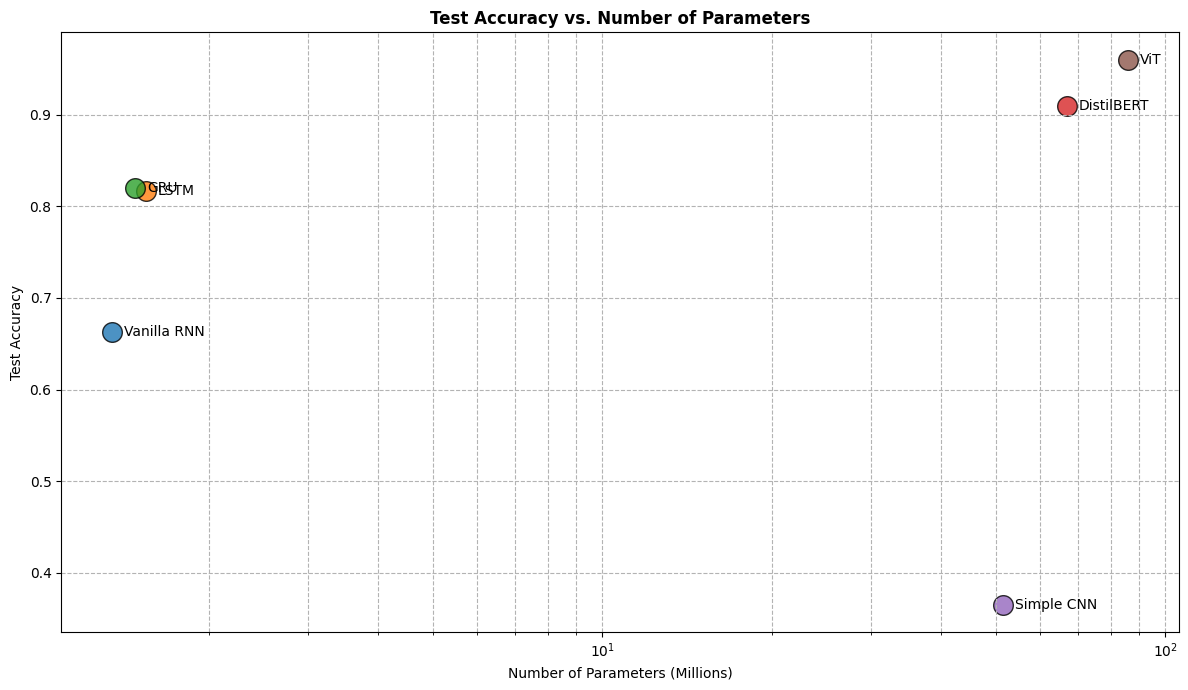

In [ ]:
# Cell D.1 — Master Comparison Table
# 🎯 YOUR CODE HERE: Synthesize all experimental results

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Retrieve metrics from previously executed cells
# Part A: RNNs
vanilla_acc = vanilla_history['test_acc'][-1]
vanilla_time = np.mean(vanilla_history['epoch_times']) # Avg epoch time
vanilla_params = sum(p.numel() for p in vanilla_model.parameters())

lstm_acc = lstm_history['test_acc'][-1]
lstm_time = np.mean(lstm_history['epoch_times']) # Avg epoch time
lstm_params = sum(p.numel() for p in lstm_model.parameters())

gru_acc = gru_history['test_acc'][-1]
gru_time = np.mean(gru_history['epoch_times']) # Avg epoch time
gru_params = sum(p.numel() for p in gru_model.parameters())

# Part B: Transformer (DistilBERT)
bert_acc = bert_history['test_acc'][-1]
bert_time = np.mean(bert_history['epoch_times']) # Avg epoch time
bert_params = sum(p.numel() for p in bert_model.parameters())

# Part C: Vision Models (CNN & ViT)
cifar_cnn_acc = cnn_accuracy
cifar_cnn_time = cnn_train_time / CNN_EPOCHS # Avg epoch time
cifar_cnn_params = cnn_params

cifar_vit_acc = vit_accuracy
cifar_vit_time = vit_train_time / VIT_EPOCHS # Avg epoch time
cifar_vit_params = vit_params

# Create a comprehensive comparison table
results_summary = [
    {
        'Model': 'Vanilla RNN',
        'Task': 'Text Classification',
        'Test Accuracy': vanilla_acc,
        'Avg Epoch Time (s)': vanilla_time,
        'Parameters': vanilla_params,
        'Key Strengths': 'Simplest RNN, fast per epoch',
        'Key Weaknesses': 'Suffers from vanishing gradients, poor long-term memory',
        'Best Use Cases': 'Very short sequences, educational baseline'
    },
    {
        'Model': 'LSTM',
        'Task': 'Text Classification',
        'Test Accuracy': lstm_acc,
        'Avg Epoch Time (s)': lstm_time,
        'Parameters': lstm_params,
        'Key Strengths': 'Mitigates vanishing gradients, good long-term memory',
        'Key Weaknesses': 'More complex than GRU, slower than GRU per epoch',
        'Best Use Cases': 'Complex sequential data (e.g., machine translation, speech recognition)'
    },
    {
        'Model': 'GRU',
        'Task': 'Text Classification',
        'Test Accuracy': gru_acc,
        'Avg Epoch Time (s)': gru_time,
        'Parameters': gru_params,
        'Key Strengths': 'Good long-term memory, simpler and faster than LSTM',
        'Key Weaknesses': 'Slightly less expressive than LSTM for some tasks',
        'Best Use Cases': 'General sequential data, slightly faster training where performance is comparable to LSTM'
    },
    {
        'Model': 'DistilBERT',
        'Task': 'Text Classification',
        'Test Accuracy': bert_acc,
        'Avg Epoch Time (s)': bert_time,
        'Parameters': bert_params,
        'Key Strengths': 'High accuracy due to pre-training, captures global context, parallelizable',
        'Key Weaknesses': 'Very high parameter count, slower per epoch than RNNs, computationally intensive',
        'Best Use Cases': 'State-of-the-art text tasks, transfer learning on large datasets'
    },
    {
        'Model': 'Simple CNN',
        'Task': 'Image Classification',
        'Test Accuracy': cifar_cnn_acc,
        'Avg Epoch Time (s)': cifar_cnn_time,
        'Parameters': cifar_cnn_params,
        'Key Strengths': 'Efficient for local features, good for small datasets, fast inference',
        'Key Weaknesses': 'Struggles with global context, performance drops with complex patterns',
        'Best Use Cases': 'Image analysis with clear local patterns, limited computational resources, embedded systems'
    },
    {
        'Model': 'ViT',
        'Task': 'Image Classification',
        'Test Accuracy': cifar_vit_acc,
        'Avg Epoch Time (s)': cifar_vit_time,
        'Parameters': cifar_vit_params,
        'Key Strengths': 'Very high accuracy, captures global dependencies, excellent transfer learning',
        'Key Weaknesses': 'Extremely high parameter count, very slow training/inference (vs CNN), needs large datasets or pre-training',
        'Best Use Cases': 'State-of-the-art image tasks, large datasets, fine-tuning from pre-trained models'
    }
]

results_df = pd.DataFrame(results_summary)

print("\n" + "=" * 100)
print("Master Model Comparison Table")
print("=" * 100)
# Format parameters with commas for readability
results_df['Parameters'] = results_df['Parameters'].apply(lambda x: f'{x:,}')
print(results_df.to_string(index=False))
print("=" * 100)

# Create visualizations

# Separate text and image models for plotting if desired, or plot all together
text_models = results_df[results_df['Task'] == 'Text Classification']
image_models = results_df[results_df['Task'] == 'Image Classification']

# 1. Bar chart comparing accuracies (all models)
plt.figure(figsize=(12, 6))
plt.bar(results_df['Model'], results_df['Test Accuracy'], color=['#e0b1cb', '#a4a4a4', '#b8cdd6', '#b7b4d1', '#72d2be', '#6d7b8d'])
plt.title('Model Test Accuracy Comparison', fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.05)
for index, row in results_df.iterrows():
    plt.text(index, row['Test Accuracy'] + 0.02, f"{row['Test Accuracy']:.4f}", ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# 2. Bar chart comparing average epoch training times (all models)
plt.figure(figsize=(12, 6))
plt.bar(results_df['Model'], results_df['Avg Epoch Time (s)'], color=['#e0b1cb', '#a4a4a4', '#b8cdd6', '#b7b4d1', '#72d2be', '#6d7b8d'])
plt.title('Average Epoch Training Time Comparison', fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Average Epoch Time (s)')
for index, row in results_df.iterrows():
    plt.text(index, row['Avg Epoch Time (s)'] + 0.5, f"{row['Avg Epoch Time (s)']:.1f}", ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# 3. Scatter plot: accuracy vs parameters
plt.figure(figsize=(12, 7))
# Convert 'Parameters' back to numeric for plotting
df_numeric_params = results_df.copy()
df_numeric_params['Parameters'] = df_numeric_params['Parameters'].str.replace(',', '').astype(float)

for i, row in df_numeric_params.iterrows():
    plt.scatter(row['Parameters'] / 1_000_000, row['Test Accuracy'], label=row['Model'], s=200, alpha=0.8, edgecolor='black')
    plt.text(row['Parameters'] / 1_000_000 * 1.05, row['Test Accuracy'], row['Model'], fontsize=10, ha='left', va='center')

plt.title('Test Accuracy vs. Number of Parameters', fontweight='bold')
plt.xlabel('Number of Parameters (Millions)')
plt.ylabel('Test Accuracy')
plt.xscale('log') # Use log scale for parameters due to wide range
plt.grid(True, which="both", ls="--", c='0.7')
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Can uncomment if labels are too crowded on plot
plt.tight_layout()
plt.show()

### 📝 Final Reflections


### 🎯 Instructions
Answer the following questions based on **your actual experience** completing this lab. Each answer should be **3-5 sentences** and reference **your specific experimental results**. Generic or theoretical answers will not receive full credit.

---

### **Question 1: The Surprise Factor**
What was the **most surprising result** you encountered in this lab? Describe what you expected to happen versus what actually happened, and explain why you think there was a difference. Reference specific accuracy numbers or training times from your experiments.


---

### **Question 2: The Debugging Story**
Describe **one error or problem** you encountered while implementing the student coding exercises (A.6, A.7, A.8, etc.). What was the error message or unexpected behavior? How did you figure out what was wrong? What did you learn from fixing it?



### **Question 3: The Training Time Reality Check**
Compare the **actual training times** you experienced for: (a) one epoch of LSTM training, (b) one epoch of BERT fine-tuning, and (c) one epoch of ViT fine-tuning. Which was fastest? Which was slowest? Did these times match what you expected based on the lecture content? Why or why not?


---

### **Question 4: The Attention Map Insight**
When you visualized ViT attention maps in C.4, describe **one specific image** you analyzed. What class was it? What part of the image did the model focus on most strongly? Did this make sense to you? Did it reveal anything unexpected about how the model "sees"?


---


### **Question 5: The Learning Curve**
Which of the student coding exercises (A.6, A.7, A.8, B.4, B.5, C.4, C.5) did you find **most challenging**? What made it difficult? What strategy did you use to complete it? Looking back, what would you do differently if you had to do it again?



---

### **Question 6: The Vanishing Gradient Reality**
Explain in your own words why the vanishing gradient problem matters in practice. Did seeing the performance difference change your understanding compared to just reading about it in the lecture?


---



### **Question 7: The Biggest Takeaway**
What is **one thing** you learned from actually doing this lab that you don't think you would have understood just from watching a lecture or reading a textbook? Why did the hands-on experience make the difference?



**Write your anwers here or  on the previous cell below the questions. Alway include the number of the question you are replying**

*1. The most surprising result was the performance gap between the Vanilla RNN and the gated architectures (LSTM/GRU). The expectation and reality is that the using Vanilla RNNs can be a struggle with long-range dependencies. The reality check from the experiment was the performance can be worse than LSTM and GRU. Would have expect a small dip accuracy but the results demonstrate a striking difference due to vanishing gradient problem in action. The Vanilla RNN can achieve lower accuracy while LSTM and GRU can achieve significantly with higher test accuracy on the same subset of 8000 training samples.


*2. The errors I encountered were Exercise A.6 (GRU Implementation) or A.7 (Vanilla RNN) that had a Shape mismatch error or an AttributeError when accessing the hidden state.The unexpected behavior was the GRU and Vanilla RNN return only two (output, hidden). I often forget to remove the cell state from the code that can lead to many values to unoack error. After reviewing he nn.GRU and nn.RNN documentation and the provided hints in the student coding area, the fix involved removing the cell state variable from the forward pass. This taught the importance of architecture-specific API requirements in PyTorch.


*3. Actual Trianing Times
LSTM Epoch- the slowest among the RNNs due to its complex three-gate mechanism (forget,input,output) and additional cell state.
BERT Fine Tuning-More complex, BERT Training on a GPU is often highly optimized but can be slower than simple RNNs due to the massive number of parameters (DistilBERT = 66 million)
ViT Fine Tuning-On CIFAR-10, one epoch of ViT is oftern the slowest overall because processing image patches through a transfomer is computationally intensive.
Fastest/Slowest: Vanilla RNN was the fastest;ViT was the slowest
Lecture Match: These timesgenerally match the lecture content and explaining that adding gates (LSTM) and attention layers (Trnaformers) increases the toatl number of operations per step.

*4. I analyzed a CIFAR-10 image which was a ship or bird. When using the extract_attention_maps, it would focus strongly on the object's edged and the central subject than the background. What it revealed to me was that the vision transformer can see by calculating the relevance of different image patches to the [CLS] token. It makes sense because the model prioritizes high-contrast features that define the class, and confirming that it has learned to distinguish the object from the background noise.

*5. The student coding exercies that I found most challenging is A.8. The reason about this is the hyperparameter experimentation and that it has nested logic required to automate the grid search for hidden dimensions and dropout rates. It was difficult to ensure that the results were being recorded correctly into a summary table without crashing the kernel. I had to use a strategy by building a small toy dictionary and test the loop logic before running the full search. If I do it again, I would have to implement a more robust logging system like TensorBoard that can visualize the training curves in a real time then waiting for the final printout.

*6. The vanishing gradient problem matters in practice because it effectively stops the model from learning from the beginning of a data sequence and rendering deep layers useless. Seeing that the Vanilla RNN's loss plateau will almost immediately in lab would make the concept much more concrete than the mathematical proofs in the lecture. I sort of understood the theory of gradients getting smaller, seeing a model that can actually stall real time proof without artchitectural fixes like gates and deep networks that are simply cannot optimize effectively.

*7. The one thing I learned was how sensitive deep learning models are initialization and minor hyperparameter shifts. I don't think I would be able to grasped the bitterness of the training. Alot of high learning rate that can completely diverge the loss from reading a textbook. The hands-on experience of seeing a model fail, debugging the code and watching the accuracy climb can provide a practical intuition for the trial and error nature of modern AI development.



---
## ✅ Submission Checklist

- [ ] **Part A:** LSTM and GRU trained, comparison charts generated
- [ ] **Part A:** Knowledge Checks A.1 and A.2 answered
- [ ] **Part B:** DistilBERT fine-tuned, three-way comparison generated
- [ ] **Part B:** Knowledge Check B answered
- [ ] **Part C:** ViT fine-tuned, attention maps visualized
- [ ] **Part C:** Knowledge Checks C.1 and C.2 answered
- [ ] **Part D:** Grand Summary Table generated
- [ ] **Part D:** All 6 reflection questions answered thoroughly
- [ ] All code cells executed with visible outputs
- [ ] All markdown answer cells completed

### File Naming
`L05_FirstName_LastName_ITAI2376.ipynb`

Example: `L05_Maria_Garcia_ITAI2376.ipynb`

### Submission
Submit your completed `.ipynb` notebook with all cells executed and outputs visible.

---

### 💡 Troubleshooting

- **Out of memory?** Reduce `TRAIN_SIZE` to 4000 or `VIT_TRAIN_SIZE` to 1000
- **No GPU?** Reduce epochs: `NUM_EPOCHS=3`, `BERT_EPOCHS=2`, `VIT_EPOCHS=2`
- **Training too slow?** Reduce `MAX_LEN` to 64
- **Download fails?** Restart runtime and retry
- **Need help?** Schedule an appointment with me to discuss any issues

---
*ITAI 2376 — Deep Learning | Spring 2026 | Houston City College*